## 1. Introduction
This notebook demonstrates the implementation of DNN, CNN, and LSTM models for churn prediction.

## 2. Data Exploration
We first explore and visualize the dataset to understand its structure.

## 3. Data Preprocessing
We preprocess the dataset to ensure quality inputs for modeling.

## 4. Model Building
We develop and evaluate three deep learning models: DNN, CNN, and LSTM.

## 5. Hyperparameter Tuning
We optimize model performance using Random Search and Keras Tuner.

## 6. Model Evaluation and Results
We compare models based on classification metrics and confusion matrices.

## 7. Conclusion and Future Work
We discuss key findings and possible future improvements.


#***Understanding the Dataset***

We first explore and visualize the dataset to understand its structure.

##**Import Libraries**
In this step, we load the dataset into a pandas DataFrame for analysis.

In [ ]:
!pip install -q keras-tuner
!pip install tensorflow
!pip install sdv


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.5/159.5 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.9/139.9 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.4/193.4 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.2/85.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7

In [ ]:
# General-purpose libraries
import numpy as np
import pandas as pd
import shutil
import warnings
warnings.filterwarnings("ignore")
from collections import Counter

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras - Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend as K, layers
from tensorflow.keras.models import Sequential, load_model, Model
from tensorflow.keras.layers import (InputLayer, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, LSTM, BatchNormalization,
                                     LeakyReLU, Bidirectional, Input, Embedding, Reshape, Concatenate, GRU, GlobalMaxPooling1D,
                                     Activation, MultiHeadAttention, LayerNormalization, Add, PReLU, ELU)
from tensorflow.keras.optimizers import (Adam, AdamW, SGD, RMSprop, Adamax, Nadam)
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback, LearningRateScheduler)
from tensorflow.keras.metrics import AUC, Recall
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.activations import swish
from tensorflow.keras.regularizers import l2

# Keras
from keras import regularizers
from keras.saving import save_model

# Keras Tuner
import keras_tuner as kt
from kerastuner.tuners import RandomSearch

# PyTorch
import torch

# Imbalanced-learn
from imblearn.over_sampling import (SMOTE, ADASYN, BorderlineSMOTE, RandomOverSampler, KMeansSMOTE)
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.pipeline import Pipeline

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler
from sklearn.utils import class_weight, compute_class_weight, shuffle
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score,precision_recall_curve, roc_curve,
                             auc, f1_score, recall_score, precision_score, precision_recall_fscore_support)
from sklearn.cluster import DBSCAN, KMeans
from sklearn.manifold import TSNE
from sklearn.feature_selection import SelectKBest, f_classif

# Synthetic Data
from sdv.single_table.ctgan import CTGAN


##Load Dataset
In this step we read The dataset

In [ ]:
df = pd.read_csv('/content/Churn_Modelling.csv')

##Data Inspection
Here we try to understand The Data

In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [ ]:
df[df.duplicated()]


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


In [ ]:
df['Exited'].value_counts()


,count
Exited,
0,7963
1,2037


In [ ]:
# Numeric columns to check
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

# Outlier detection using IQR
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")


CreditScore: 15 outliers
Age: 359 outliers
Tenure: 0 outliers
Balance: 0 outliers
NumOfProducts: 60 outliers
EstimatedSalary: 0 outliers


In [ ]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [ ]:
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [ ]:
df.corr(numeric_only=True)


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
RowNumber,1.000000,0.004202,0.005840,0.000783,-0.006495,-0.009067,0.007246,0.000599,0.012044,-0.005988,-0.016571
CustomerId,0.004202,1.000000,0.005308,0.009497,-0.014883,-0.012419,0.016972,-0.014025,0.001665,0.015271,-0.006248
CreditScore,0.005840,0.005308,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Age,0.000783,0.009497,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,-0.006495,-0.014883,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,-0.009067,-0.012419,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.007246,0.016972,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,0.000599,-0.014025,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
IsActiveMember,0.012044,0.001665,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
EstimatedSalary,-0.005988,0.015271,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097


In [ ]:
df.skew(numeric_only=True)


,0
RowNumber,0.000000
CustomerId,0.001149
CreditScore,-0.071607
Age,1.011320
Tenure,0.010991
Balance,-0.141109
NumOfProducts,0.745568
HasCrCard,-0.901812
IsActiveMember,-0.060437
EstimatedSalary,0.002085


In [ ]:
# Check distribution of 'Exited' column
exit_counts = df['Exited'].value_counts()
print("Exited distribution:\n", exit_counts)

# Percentage distribution
exit_percent = df['Exited'].value_counts(normalize=True) * 100
print("\nPercentage:\n", exit_percent.round(2))

Exited distribution:
 Exited
0    7963
1    2037
Name: count, dtype: int64

Percentage:
 Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


#**Visualization**

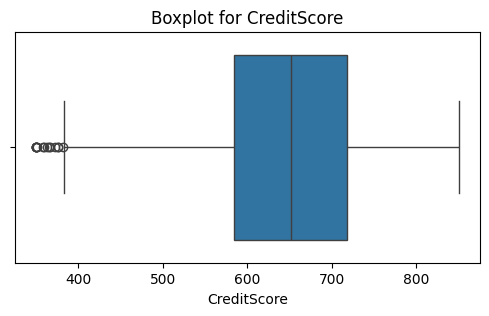

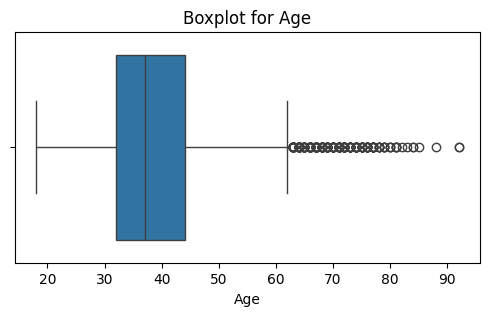

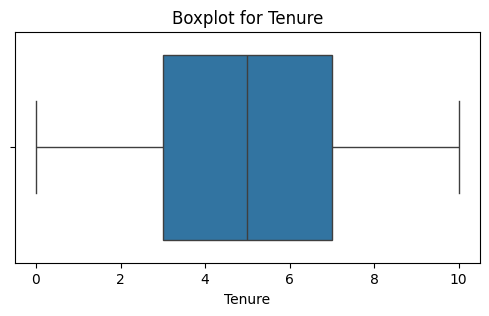

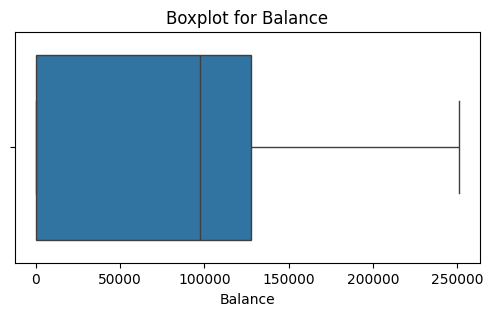

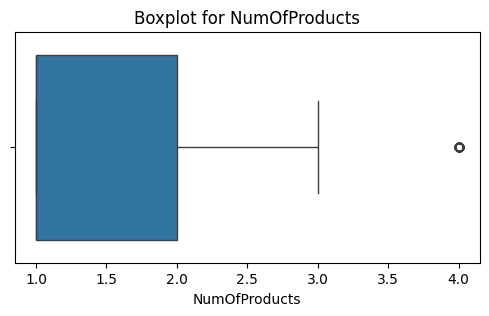

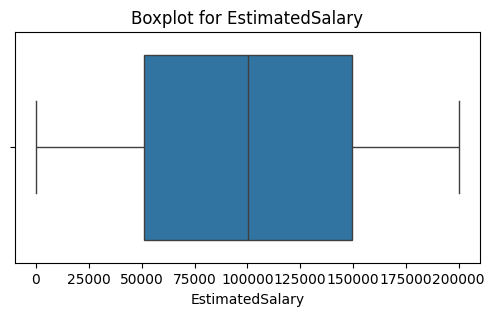

In [ ]:
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot for {col}')
    plt.show()


Barplot – Geography

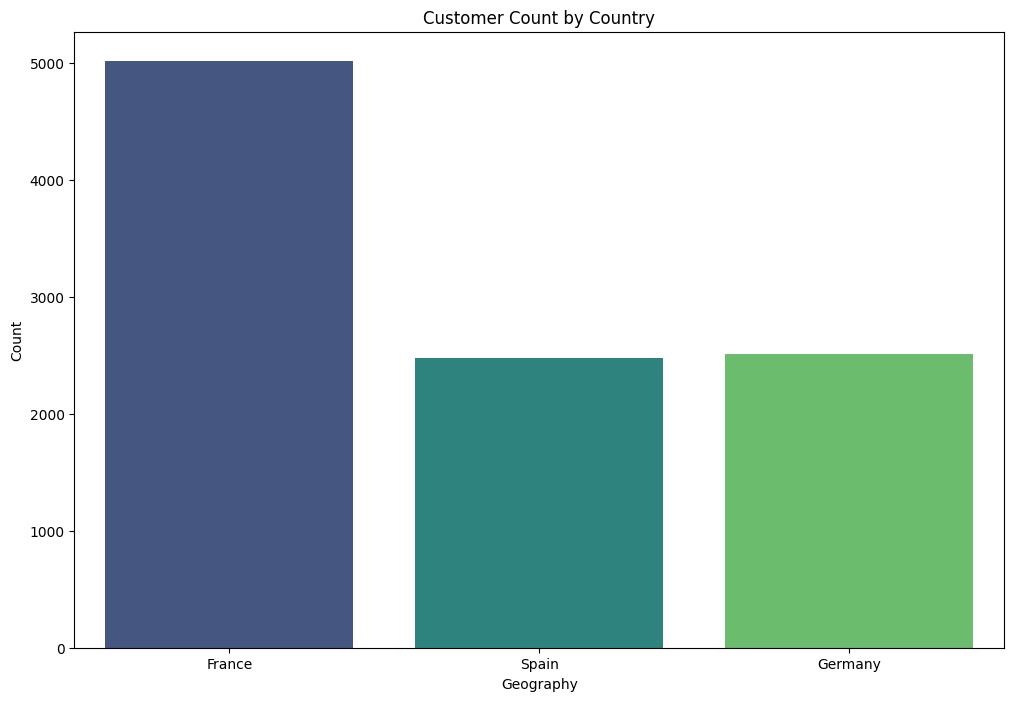

In [ ]:
plt.figure(figsize=(12,8))
sns.countplot(data=df, x='Geography', palette='viridis')
plt.title('Customer Count by Country')
plt.xlabel('Geography')
plt.ylabel('Count')
plt.show()


Barplot – Age (Top 5 frequent ages)

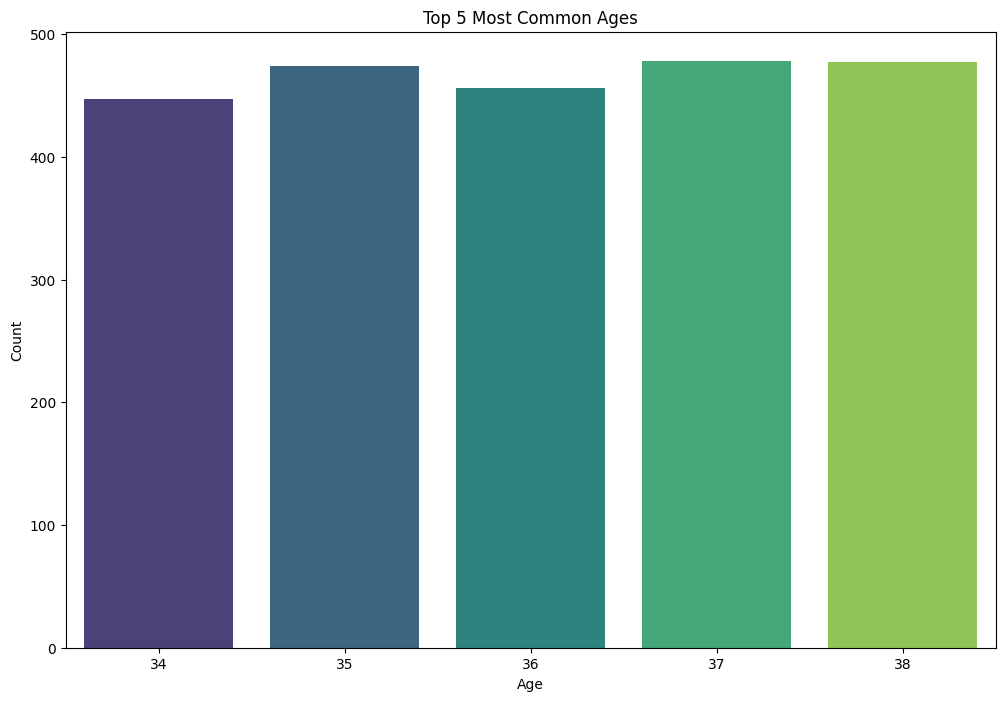

In [ ]:
top5_age = df['Age'].value_counts().head(5)
plt.figure(figsize=(12,8))
sns.barplot(x=top5_age.index, y=top5_age.values, palette='viridis')
plt.title('Top 5 Most Common Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

Barplot – Tenure

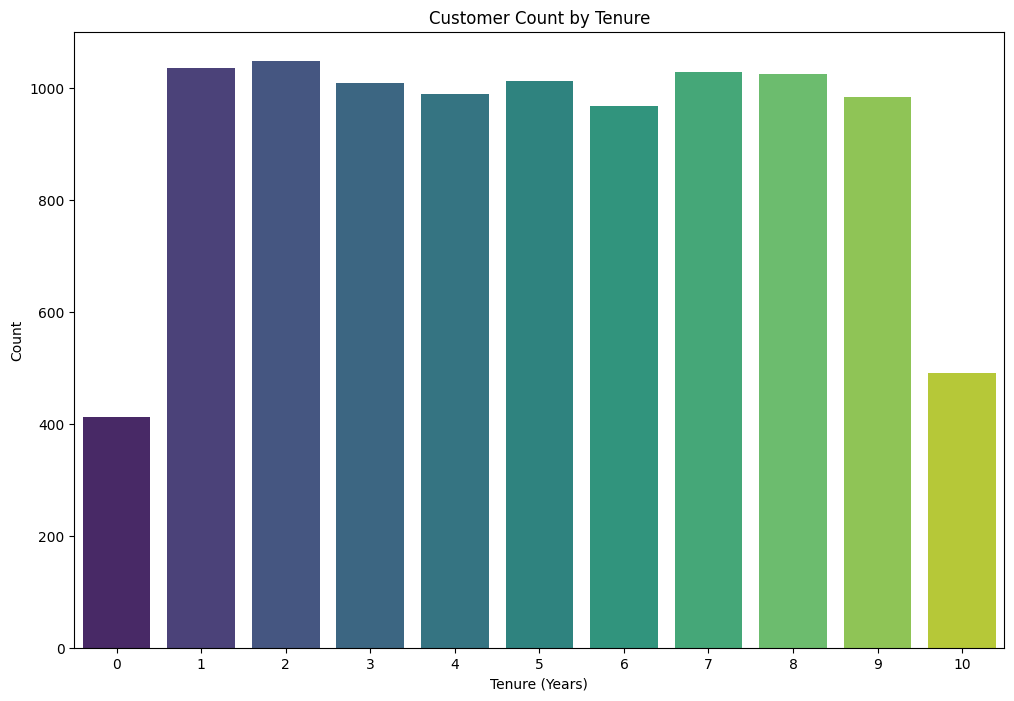

In [ ]:
plt.figure(figsize=(12,8))
sns.countplot(data=df, x='Tenure', palette='viridis')
plt.title('Customer Count by Tenure')
plt.xlabel('Tenure (Years)')
plt.ylabel('Count')
plt.show()


Barplot – NumOfProducts

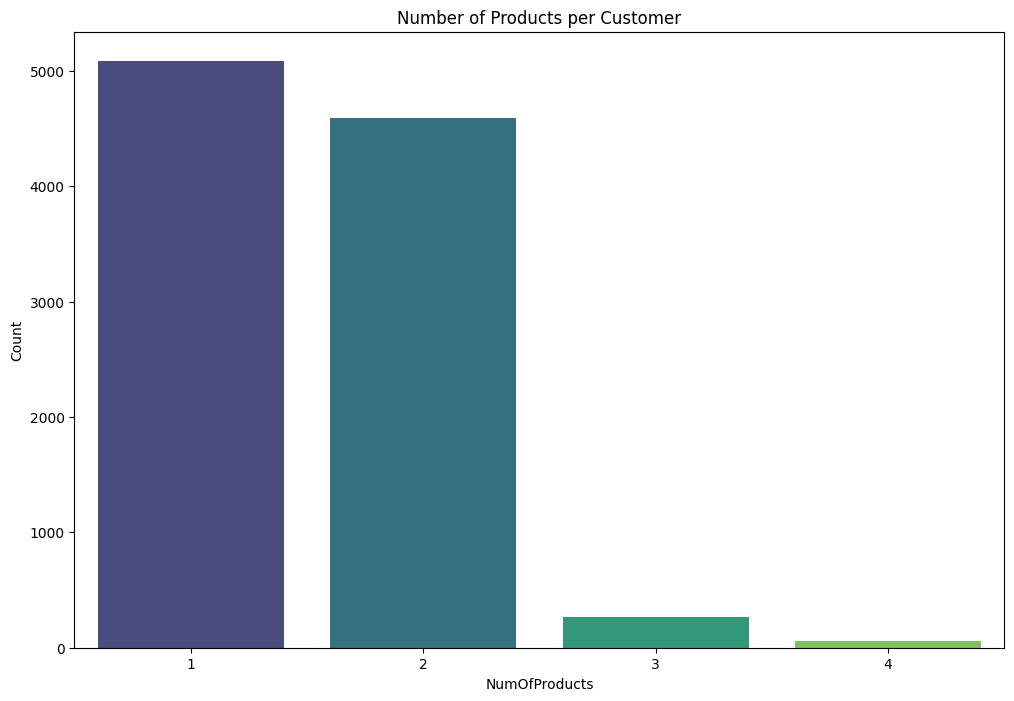

In [ ]:
plt.figure(figsize=(12,8))
sns.countplot(data=df, x='NumOfProducts', palette='viridis')
plt.title('Number of Products per Customer')
plt.xlabel('NumOfProducts')
plt.ylabel('Count')
plt.show()


Pie Chart – Gender

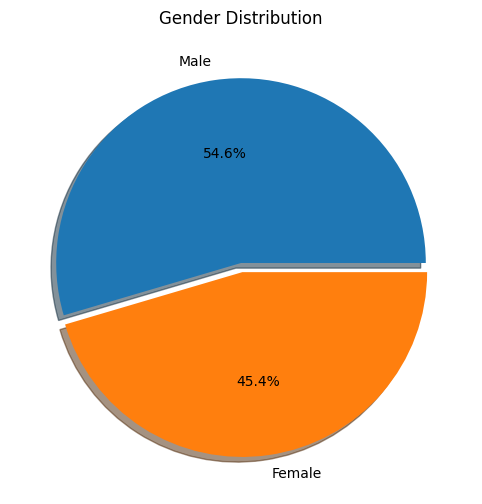

In [ ]:
gender_count = df['Gender'].value_counts()
explode = (0, 0.05)
gender_count.plot.pie(autopct='%.1f%%', explode=explode, figsize=(8, 6), shadow=True)
plt.title('Gender Distribution')
plt.ylabel('')
plt.show()


Pie Chart – HasCrCard

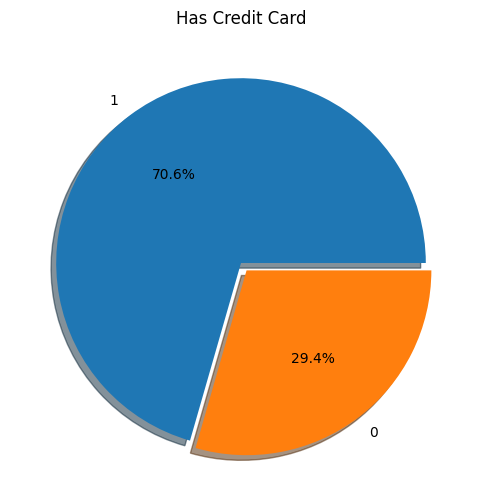

In [ ]:
crcard_count = df['HasCrCard'].value_counts()
explode = (0, 0.05)
crcard_count.plot.pie(autopct='%.1f%%', explode=explode, figsize=(8, 6), shadow=True)
plt.title('Has Credit Card')
plt.ylabel('')
plt.show()


Pie Chart – IsActiveMember

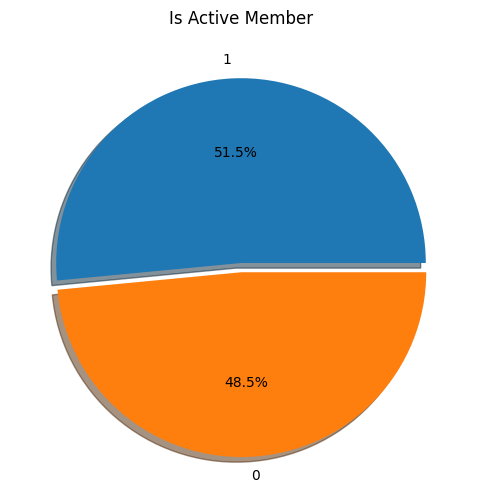

In [ ]:
active_count = df['IsActiveMember'].value_counts()
explode = (0, 0.05)
active_count.plot.pie(autopct='%.1f%%', explode=explode, figsize=(8, 6), shadow=True)
plt.title('Is Active Member')
plt.ylabel('')
plt.show()


Pie Chart – Exited

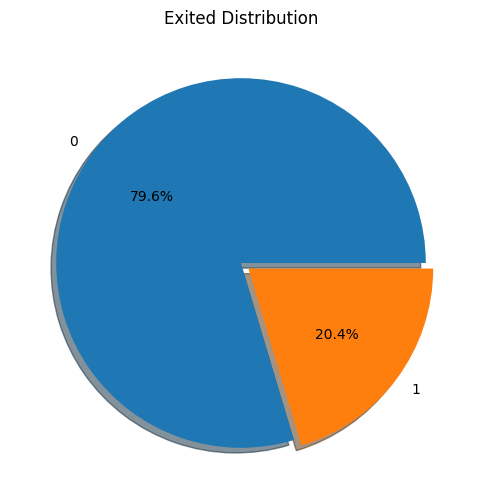

In [ ]:
exited_count = df['Exited'].value_counts()
explode = (0, 0.05)
exited_count.plot.pie(autopct='%.1f%%', explode=explode, figsize=(8, 6), shadow=True)
plt.title('Exited Distribution')
plt.ylabel('')
plt.show()


FacetGrid – Geography vs Exited

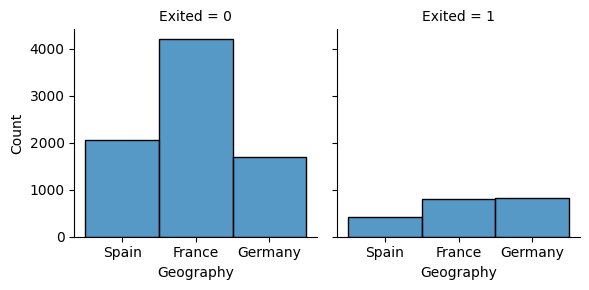

In [ ]:
g = sns.FacetGrid(df, col='Exited')
g.map_dataframe(sns.histplot, x='Geography')
plt.show()


FacetGrid – Age vs Exited

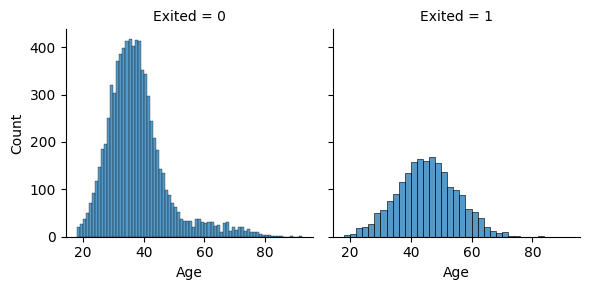

In [ ]:
g = sns.FacetGrid(df, col='Exited')
g.map_dataframe(sns.histplot, x='Age')
plt.show()


FacetGrid – Gender vs Exited

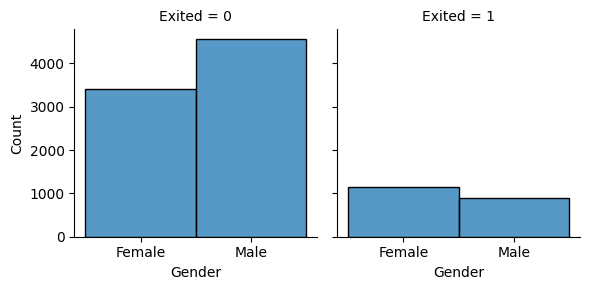

In [ ]:
g = sns.FacetGrid(df, col='Exited')
g.map_dataframe(sns.histplot, x='Gender')
plt.show()


FacetGrid – Tenure vs Exited

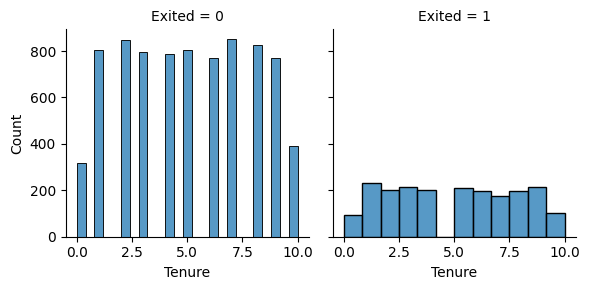

In [ ]:
g = sns.FacetGrid(df, col='Exited')
g.map_dataframe(sns.histplot, x='Tenure')
plt.show()


FacetGrid – NumOfProducts vs Exited

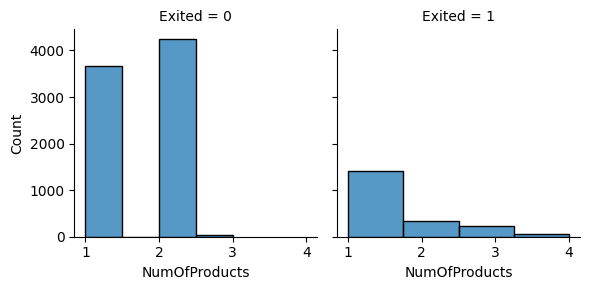

In [ ]:
g = sns.FacetGrid(df, col='Exited')
g.map_dataframe(sns.histplot, x='NumOfProducts', bins=4)
plt.show()


Balancing

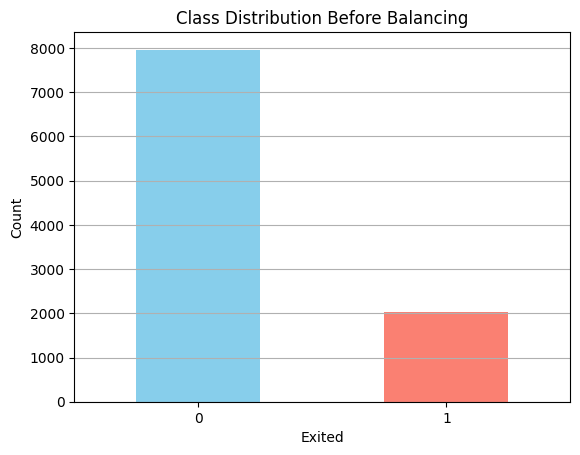

In [ ]:
y = df['Exited']

# Original class distribution
y.value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Class Distribution Before Balancing')
plt.xlabel('Exited')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

# **Preprocessing**
We preprocess the dataset to ensure quality inputs for modeling.

## Feature Quality

In [ ]:
df.drop(columns=["RowNumber", "CustomerId", "Surname"], inplace=True)


##Fearure Engineering

###Feature & Target Definition

In [ ]:
print(df.columns)


Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')


In [ ]:
# ----- Feature Engineering -----
df['Age_Balance'] = df['Age'] * df['Balance']
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 30, 40, 50, 60, 100], labels=[0, 1, 2, 3, 4])
df['Credit_Per_Tenure'] = df['CreditScore'] / (df['Tenure'] + 1)
df['Tenure_By_Age'] = df['Tenure'] / (df['Age'] + 1)
df['Balance_Salary_Ratio'] = df['Balance'] / (df['EstimatedSalary'] + 1)
df['Products_Active'] = df['NumOfProducts'] * df['IsActiveMember']
df['IsSeniorHighBalance'] = ((df['Age'] > 50) & (df['Balance'] > 100000)).astype(int)
df['Low_Credit_Active'] = ((df['CreditScore'] < 500) & (df['IsActiveMember'] == 1)).astype(int)
df['Young_HighBalance'] = ((df['Age'] < 30) & (df['Balance'] > 100000)).astype(int)
df['Balance_IsActive'] = df['Balance'] * df['IsActiveMember']
df['Products_CreditRatio'] = df['NumOfProducts'] / (df['CreditScore'] + 1)
df['RiskScore'] = (df['Balance'] / (df['CreditScore'] + 1)) * df['NumOfProducts']
df['Young_Inactive'] = ((df['Age'] < 30) & (df['IsActiveMember'] == 0)).astype(int)
df['Old_Active_Rich'] = ((df['Age'] > 60) & (df['EstimatedSalary'] > 100000) & (df['IsActiveMember'] == 1)).astype(int)



In [ ]:
selected_engineered = [
    'Age_Balance', 'Credit_Per_Tenure', 'Tenure_By_Age',
    'Balance_Salary_Ratio', 'Products_Active', 'Balance_IsActive',
    'Products_CreditRatio', 'RiskScore'
]

df[selected_engineered].nunique().sort_values()


,0
Products_Active,5
Tenure_By_Age,416
Products_CreditRatio,1069
Credit_Per_Tenure,3244
Balance_IsActive,3279
Age_Balance,6383
Balance_Salary_Ratio,6384
RiskScore,6384


In [ ]:
to_drop = [
    'Low_Credit_Active',
    'Young_HighBalance',
    'IsSeniorHighBalance',
    'Young_Inactive',
    'Old_Active_Rich'
]

df.drop(columns=to_drop, inplace=True)


In [ ]:
# Drop NaNs if any (ensure no nan in df)
df.dropna(inplace=True)

In [ ]:
# Apply log1p transform
df['RiskScore'] = np.log1p(df['RiskScore'])
df['Products_CreditRatio'] = np.log1p(df['Products_CreditRatio'])

# Plot updated distributions
features_transformed = ['RiskScore', 'Products_CreditRatio']


### One Hot Encode

In [ ]:
df = pd.get_dummies(df, columns=["Geography", "Gender"], drop_first=True)

### Define Features and Target

In [ ]:
X = df.drop('Exited', axis=1)
y = df['Exited']


### Handling Imbalance

In [ ]:
#ros = RandomOverSampler(random_state=42)
#X_bal, y_bal = ros.fit_resample(X, y)
#print('RandomOverSampler:', y_bal.value_counts())

In [ ]:
#adasyn = ADASYN(random_state=42)
#X_bal, y_bal = adasyn.fit_resample(X, y)
#print('ADASYN:', y_bal.value_counts())

In [ ]:
#bsmote = BorderlineSMOTE(random_state=42)
#X_bal, y_bal = bsmote.fit_resample(X, y)
#print('BorderlineSMOTE:', y_bal.value_counts())

In [ ]:
#smote = SMOTE(random_state=42)
#X_bal, y_bal = smote.fit_resample(X, y)
#print('SMOTE:', y_bal.value_counts())

In [ ]:
smote_tomek = SMOTETomek(random_state=42)
X_bal, y_bal = smote_tomek.fit_resample(X, y)
print('SMOTETomek:', y_bal.value_counts())

SMOTETomek: Exited
1    7306
0    7306
Name: count, dtype: int64


In [ ]:
#kmeans_smote = KMeansSMOTE(random_state=42, cluster_balance_threshold=0.05) # Lower the threshold
#X_bal, y_bal = kmeans_smote.fit_resample(X, y)
#print('KMeansSMOTE:', y_bal.value_counts())

### Splitting

In [ ]:
# Split balanced data
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, stratify=y_bal, random_state=42
)

print("Train:", y_train.value_counts())
print("Test:", y_test.value_counts())

Train: Exited
1    5845
0    5844
Name: count, dtype: int64
Test: Exited
0    1462
1    1461
Name: count, dtype: int64


In [ ]:
X_train = pd.DataFrame(X_train).fillna(0)
X_test = pd.DataFrame(X_test).fillna(0)

### Scalling

In [ ]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# **Visulaization after Preprocessing**

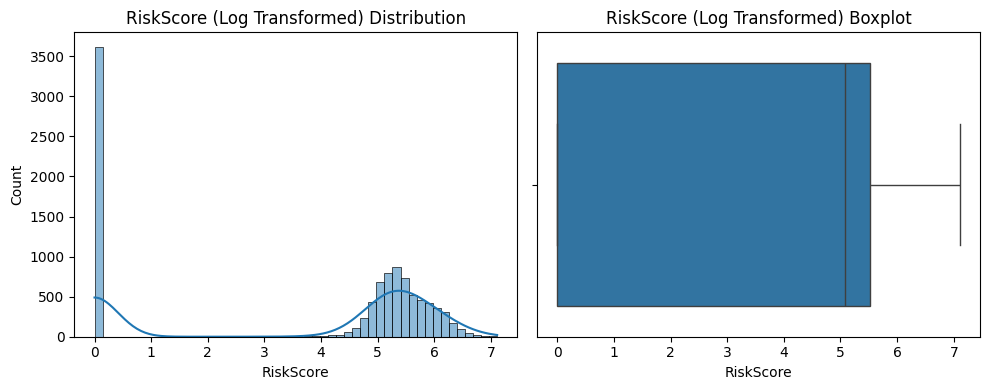

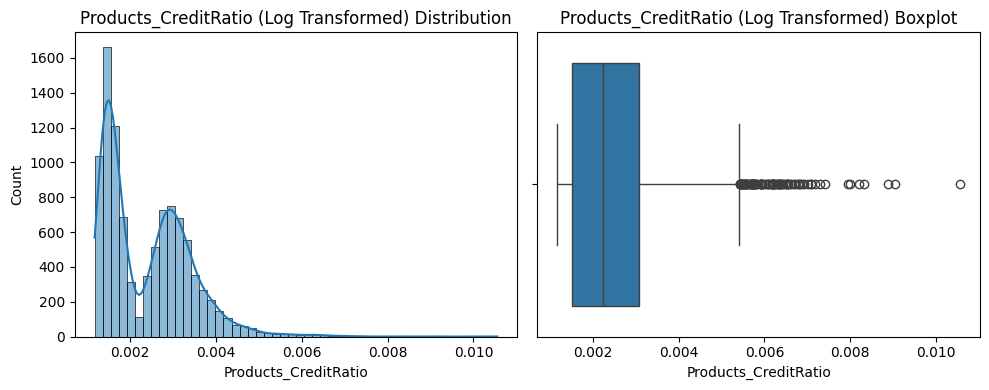

In [ ]:
for feature in features_transformed:
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    sns.histplot(df[feature], bins=50, kde=True)
    plt.title(f'{feature} (Log Transformed) Distribution')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[feature])
    plt.title(f'{feature} (Log Transformed) Boxplot')

    plt.tight_layout()
    plt.show()


Correlation Heatmap

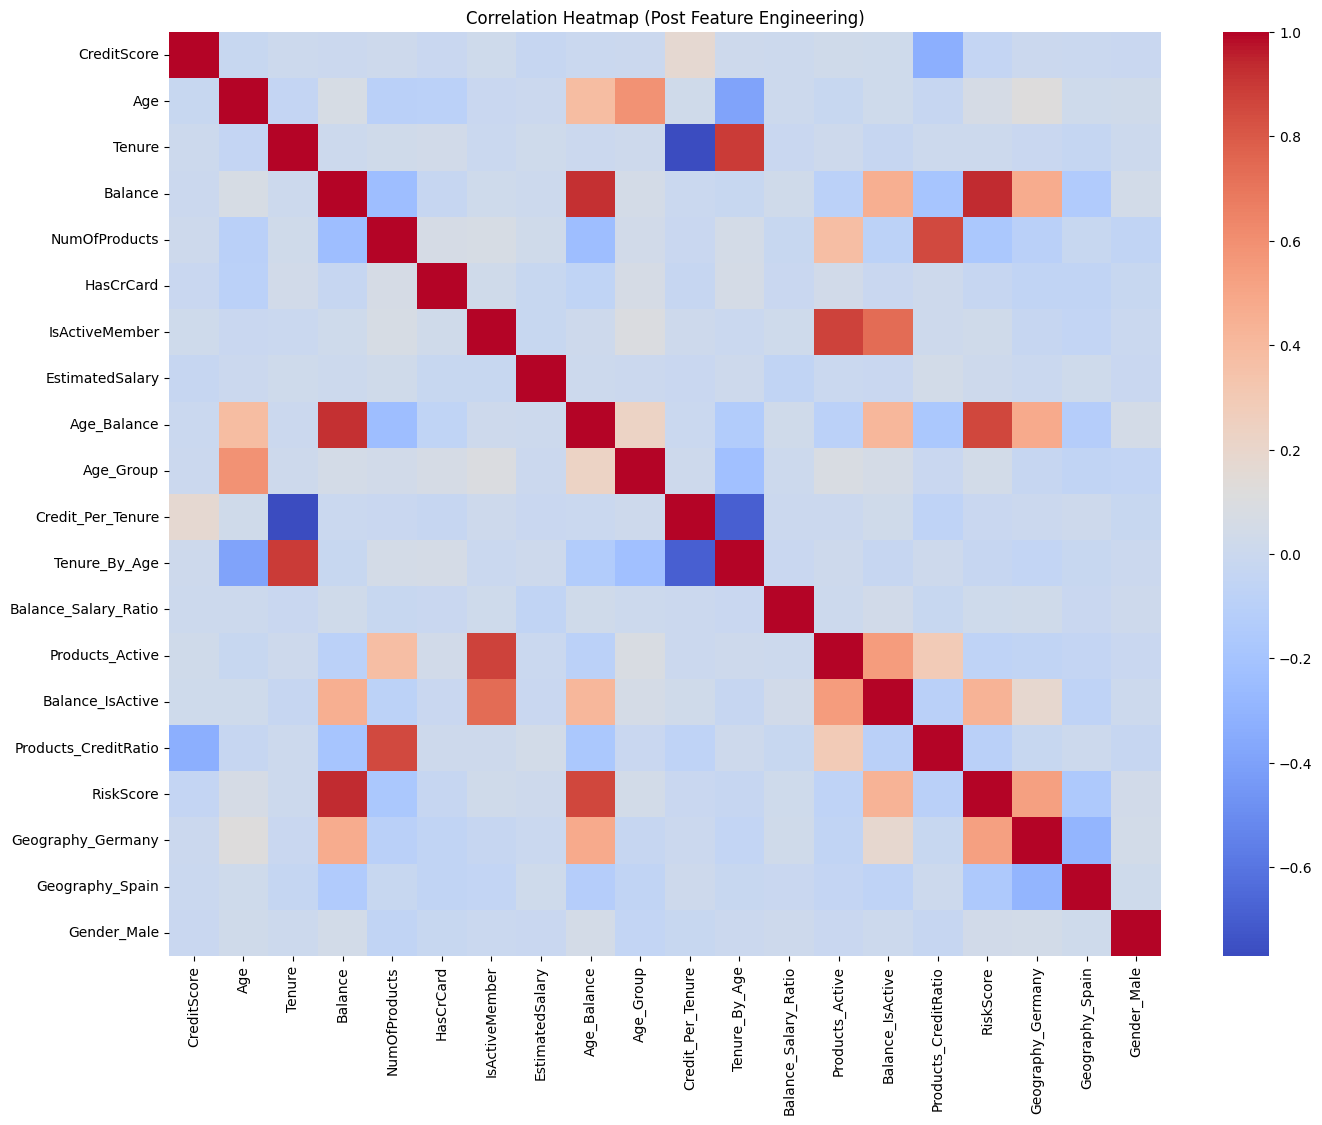

In [ ]:
plt.figure(figsize=(16, 12))
sns.heatmap(pd.DataFrame(X_train_scaled, columns=X.columns).corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap (Post Feature Engineering)")
plt.show()


Class Distribution After SMOTE

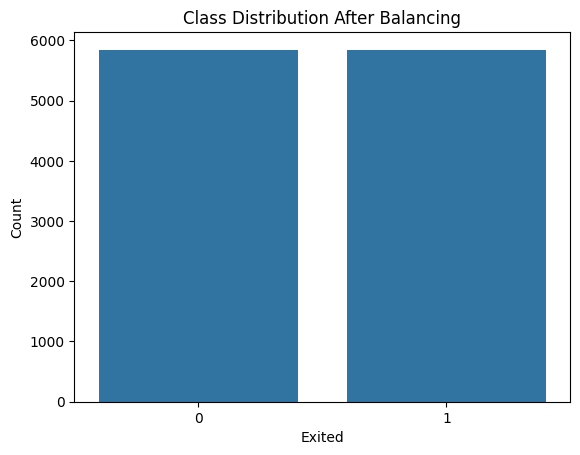

In [ ]:
# sns.countplot(x=X_train_scaled) # This line caused the error
# Instead, plot the distribution of the balanced target variable y_train
sns.countplot(x=y_train)
plt.title("Class Distribution After Balancing") # Updated title for clarity
plt.xlabel("Exited")
plt.ylabel("Count")
plt.show()

# **Model Building**

This notebook demonstrates the implementation of DNN, CNN, and LSTM models for churn prediction.

# Building DNN
We define a baseline Deep Neural Network with fully connected layers.

### Base Model

In [ ]:
dnn_model = Sequential([
    Dense(64, input_shape=(X_train_scaled.shape[1],), activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
dnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Train
history = dnn_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=128,
    verbose=1
)

Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5711 - loss: 0.6687 - val_accuracy: 0.7164 - val_loss: 0.5573
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7260 - loss: 0.5442 - val_accuracy: 0.7502 - val_loss: 0.5057
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7605 - loss: 0.5002 - val_accuracy: 0.7823 - val_loss: 0.4608
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7868 - loss: 0.4635 - val_accuracy: 0.7938 - val_loss: 0.4304
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8041 - loss: 0.4276 - val_accuracy: 0.8097 - val_loss: 0.4156
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8062 - loss: 0.4162 - val_accuracy: 0.8152 - val_loss: 0.3911
Epoch 7/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8237 - loss: 0.3924 - val_accuracy: 0.8246 - val_loss: 0.3757
Epoch 8/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8409 - loss: 0.3763 - val_accuracy: 0.8285 - 

In [ ]:
# Extract metrics
dnn_train_loss = history.history['loss']
dnn_val_loss = history.history['val_loss']
dnn_train_acc = history.history['accuracy']
dnn_val_acc = history.history['val_accuracy']

# Best epoch (lowest val_loss)
best_dnn_epoch = np.argmin(dnn_val_loss) + 1

# Print results
print(f"Best Epoch: {best_dnn_epoch}")
print(f"Training Accuracy: {dnn_train_acc[best_dnn_epoch-1]:.4f}")
print(f"Validation Accuracy: {dnn_val_acc[best_dnn_epoch-1]:.4f}")
print(f"Training Loss: {dnn_train_loss[best_dnn_epoch-1]:.4f}")
print(f"Validation Loss: {dnn_val_loss[best_dnn_epoch-1]:.4f}")


Best Epoch: 95
Training Accuracy: 0.8987
Validation Accuracy: 0.8854
Training Loss: 0.2386
Validation Loss: 0.2687


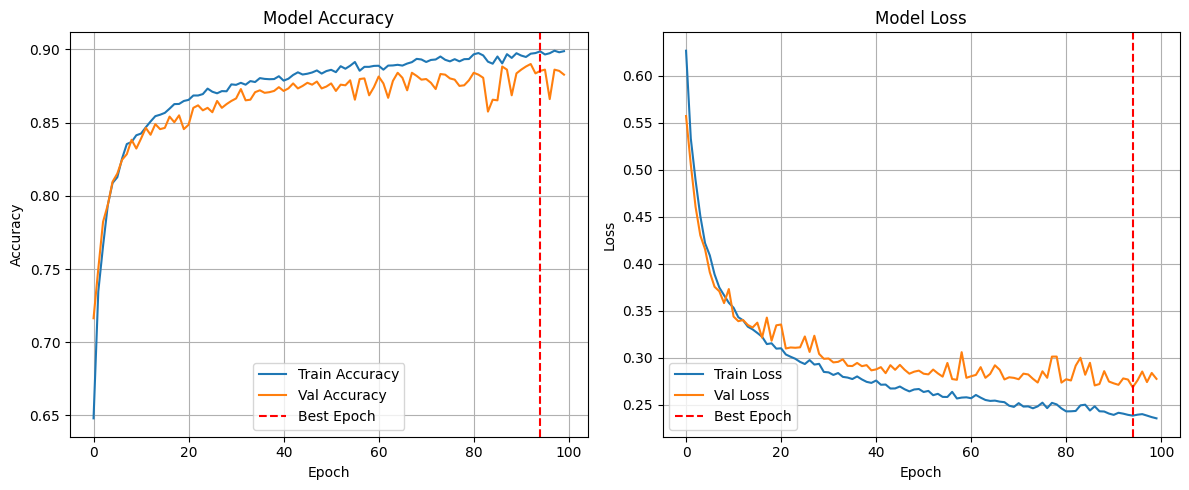

In [ ]:
# --- Plotting ---
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(dnn_train_acc, label='Train Accuracy')
plt.plot(dnn_val_acc, label='Val Accuracy')
plt.axvline(best_dnn_epoch-1, color='r', linestyle='--', label='Best Epoch')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(dnn_train_loss, label='Train Loss')
plt.plot(dnn_val_loss, label='Val Loss')
plt.axvline(best_dnn_epoch-1, color='r', linestyle='--', label='Best Epoch')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_accuracy = dnn_model.evaluate(X_test_scaled , y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


Test Accuracy: 0.8796
Test Loss: 0.2877


In [ ]:
y_pred_probs = dnn_model.predict(X_test_scaled )
y_pred = (y_pred_probs > 0.5).astype("int32")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Confusion Matrix:
[[1384   78]
 [ 274 1187]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.95      0.89      1462
           1       0.94      0.81      0.87      1461

    accuracy                           0.88      2923
   macro avg       0.89      0.88      0.88      2923
weighted avg       0.89      0.88      0.88      2923



92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


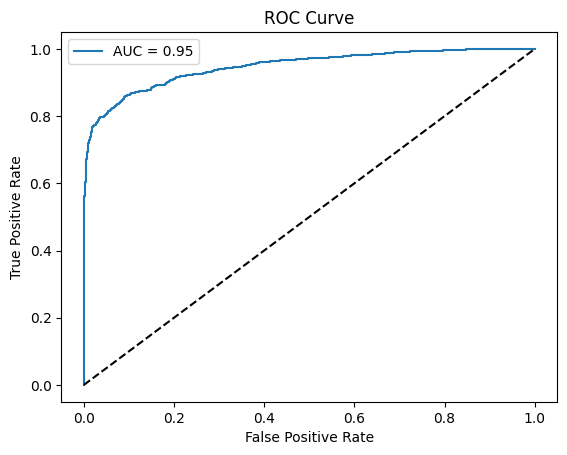

In [ ]:
y_proba = dnn_model.predict(X_test_scaled)
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


## Tuning

### Adding Layes + Batch Normalization + Dropout

In [ ]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)), BatchNormalization(),Dropout(0.4),
    Dense(64, activation='relu'), BatchNormalization(), Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=RMSprop(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,825 (54.00 KB)

 Trainable params: 13,441 (52.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6284 - loss: 0.6952 - val_accuracy: 0.7348 - val_loss: 0.6273
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7298 - loss: 0.5446 - val_accuracy: 0.7198 - val_loss: 0.6004
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7743 - loss: 0.4784 - val_accuracy: 0.7575 - val_loss: 0.5438
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7851 - loss: 0.4595 - val_accuracy: 0.7802 - val_loss: 0.4722
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8025 - loss: 0.4312 - val_accuracy: 0.7956 - val_loss: 0.4297
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8124 - loss: 0.4076 - val_accuracy: 0.8430 - val_loss: 0.3642
Epoch 7/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8300 - loss: 0.3812 - val_accuracy: 0.8477 - val_loss: 0.3406
Epoch 8/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8284 - loss: 0.3762 - val_accuracy: 0.8576 - v

In [ ]:
# Extract metrics
dnn_train_loss = history.history['loss']
dnn_val_loss = history.history['val_loss']
dnn_train_acc = history.history['accuracy']
dnn_val_acc = history.history['val_accuracy']

# Best epoch (lowest val_loss)
best_dnn_epoch = np.argmin(dnn_val_loss) + 1

# Print results
print(f"Best Epoch: {best_dnn_epoch}")
print(f"Training Accuracy: {dnn_train_acc[best_dnn_epoch-1]:.4f}")
print(f"Validation Accuracy: {dnn_val_acc[best_dnn_epoch-1]:.4f}")
print(f"Training Loss: {dnn_train_loss[best_dnn_epoch-1]:.4f}")
print(f"Validation Loss: {dnn_val_loss[best_dnn_epoch-1]:.4f}")


Best Epoch: 28
Training Accuracy: 0.8661
Validation Accuracy: 0.8755
Training Loss: 0.3055
Validation Loss: 0.2683


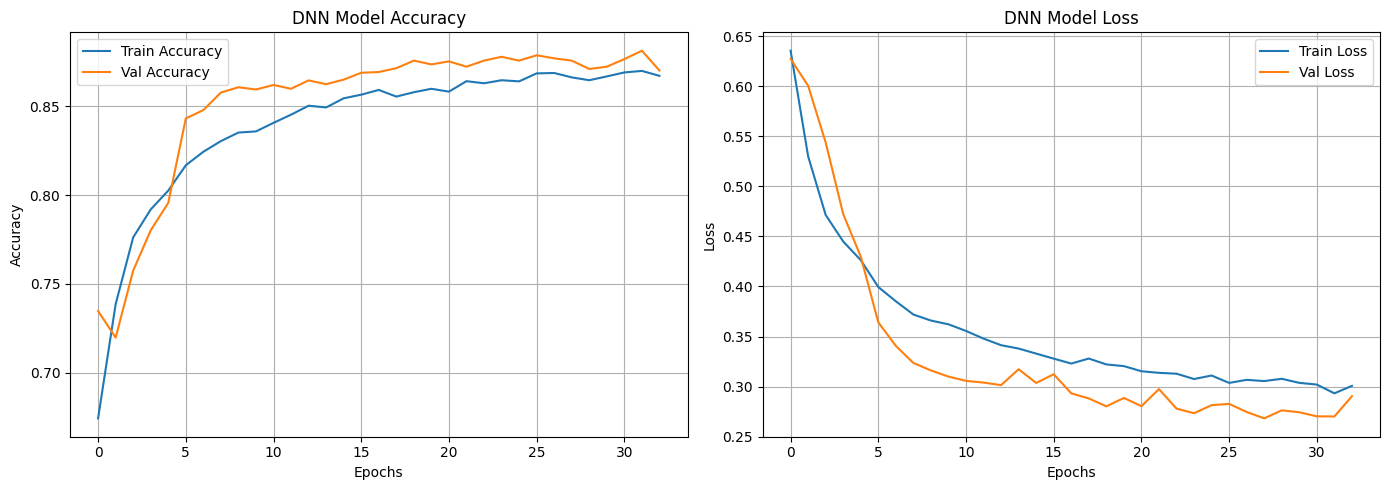

In [ ]:
# Plot accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('DNN Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('DNN Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_accuracy = dnn_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


Test Accuracy: 0.8796
Test Loss: 0.2877


In [ ]:
y_pred_probs = dnn_model.predict(X_test_scaled)
y_pred = (y_pred_probs > 0.5).astype("int32")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Confusion Matrix:
[[1384   78]
 [ 274 1187]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.95      0.89      1462
           1       0.94      0.81      0.87      1461

    accuracy                           0.88      2923
   macro avg       0.89      0.88      0.88      2923
weighted avg       0.89      0.88      0.88      2923



92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


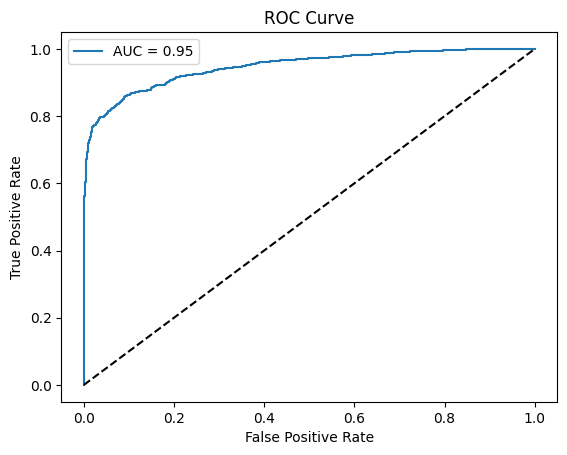

In [ ]:
y_proba = dnn_model.predict(X_test_scaled)
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


### Dense

In [ ]:
dnn_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

dnn_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
dnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,825 (54.00 KB)

 Trainable params: 13,441 (52.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


history = dnn_model.fit(
    X_train_scaled, y_train,
    validation_split =0.2,
    epochs=100,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5133 - loss: 0.7822 - val_accuracy: 0.5659 - val_loss: 0.6828
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6272 - loss: 0.6604 - val_accuracy: 0.6061 - val_loss: 0.6651
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6754 - loss: 0.6089 - val_accuracy: 0.6544 - val_loss: 0.6410
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6924 - loss: 0.5860 - val_accuracy: 0.7010 - val_loss: 0.6092
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7082 - loss: 0.5661 - val_accuracy: 0.7327 - val_loss: 0.5733
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7121 - loss: 0.5603 - val_accuracy: 0.7566 - val_loss: 0.5387
Epoch 7/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7345 - loss: 0.5419 - val_accuracy: 0.7725 - val_loss: 0.5112
Epoch 8/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7225 - loss: 0.5408 - val_accuracy: 0.7772 - v

In [ ]:
# Extract metrics
dnn_train_loss = history.history['loss']
dnn_val_loss = history.history['val_loss']
dnn_train_acc = history.history['accuracy']
dnn_val_acc = history.history['val_accuracy']

# Best epoch (lowest val_loss)
best_dnn_epoch = np.argmin(dnn_val_loss) + 1

# Print results
print(f"Best Epoch: {best_dnn_epoch}")
print(f"Training Accuracy: {dnn_train_acc[best_dnn_epoch-1]:.4f}")
print(f"Validation Accuracy: {dnn_val_acc[best_dnn_epoch-1]:.4f}")
print(f"Training Loss: {dnn_train_loss[best_dnn_epoch-1]:.4f}")
print(f"Validation Loss: {dnn_val_loss[best_dnn_epoch-1]:.4f}")


Best Epoch: 100
Training Accuracy: 0.8547
Validation Accuracy: 0.8747
Training Loss: 0.3286
Validation Loss: 0.2993


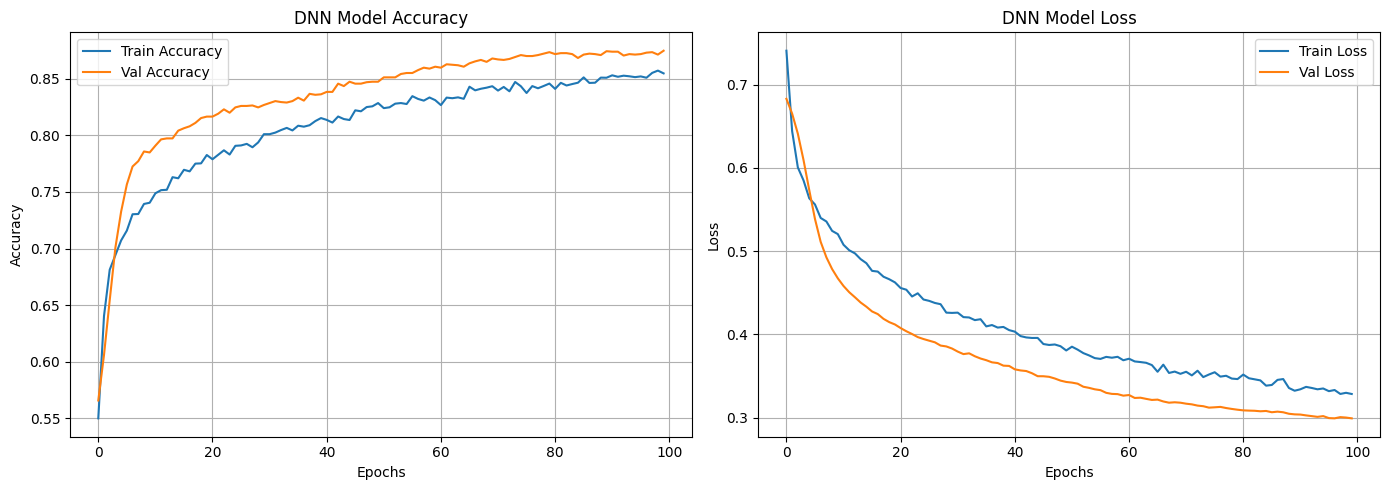

In [ ]:
# Plot accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('DNN Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('DNN Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_accuracy = dnn_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


Test Accuracy: 0.8690
Test Loss: 0.3101


In [ ]:
y_pred_probs = dnn_model.predict(X_test_scaled)
y_pred = (y_pred_probs > 0.5).astype("int32")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Confusion Matrix:
[[1350  112]
 [ 271 1190]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.88      1462
           1       0.91      0.81      0.86      1461

    accuracy                           0.87      2923
   macro avg       0.87      0.87      0.87      2923
weighted avg       0.87      0.87      0.87      2923



92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


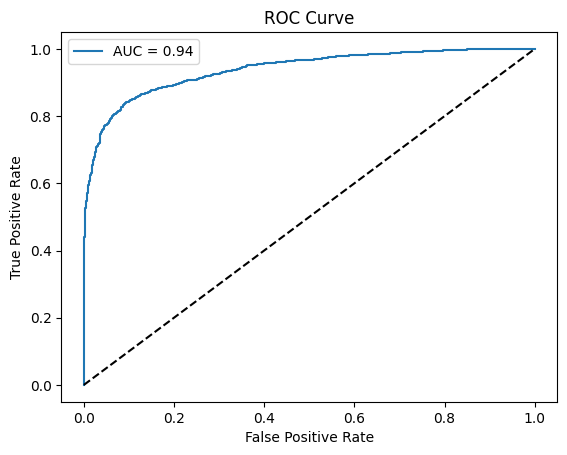

In [ ]:
y_proba = dnn_model.predict(X_test_scaled)
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


### Adding layers

In [ ]:
model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train_scaled.shape[1],), kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.2),

    Dense(16, activation='relu', kernel_regularizer=l2(1e-4)),  # NEW LAYER
    BatchNormalization(),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])
# Compile with Adam optimizer
model.compile(
    optimizer=Adamax(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 512)            │        10,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 189,761 (741.25 KB)

 Trainable params: 187,809 (733.63 KB)

 Non-trainable params: 1,952 (7.62 KB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

history = model.fit(
    X_train_scaled, y_train,
    validation_split = 0.2,
    epochs=100,
    batch_size=128,
    callbacks=[early_stop,lr_reduce],
    verbose=1
)


Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.5679 - loss: 0.8127 - val_accuracy: 0.5021 - val_loss: 0.7581 - learning_rate: 0.0010
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6588 - loss: 0.7034 - val_accuracy: 0.5252 - val_loss: 0.7462 - learning_rate: 0.0010
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6878 - loss: 0.6629 - val_accuracy: 0.5761 - val_loss: 0.7190 - learning_rate: 0.0010
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6963 - loss: 0.6537 - val_accuracy: 0.6621 - val_loss: 0.6748 - learning_rate: 0.0010
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7240 - loss: 0.6240 - val_accuracy: 0.7096 - val_loss: 0.6333 - learning_rate: 0.0010
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7341 - loss: 0.6050 - val_accuracy: 0.7365 - val_loss: 0.5987 - learning_rate: 0.0010
Epoch 7/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7398 - loss: 0.6040 - 

In [ ]:
# Extract metrics
dnn_train_loss = history.history['loss']
dnn_val_loss = history.history['val_loss']
dnn_train_acc = history.history['accuracy']
dnn_val_acc = history.history['val_accuracy']

# Best epoch (lowest val_loss)
best_dnn_epoch = np.argmin(dnn_val_loss) + 1

# Print results
print(f"Best Epoch: {best_dnn_epoch}")
print(f"Training Accuracy: {dnn_train_acc[best_dnn_epoch-1]:.4f}")
print(f"Validation Accuracy: {dnn_val_acc[best_dnn_epoch-1]:.4f}")
print(f"Training Loss: {dnn_train_loss[best_dnn_epoch-1]:.4f}")
print(f"Validation Loss: {dnn_val_loss[best_dnn_epoch-1]:.4f}")


Best Epoch: 90
Training Accuracy: 0.8712
Validation Accuracy: 0.8794
Training Loss: 0.3572
Validation Loss: 0.3344


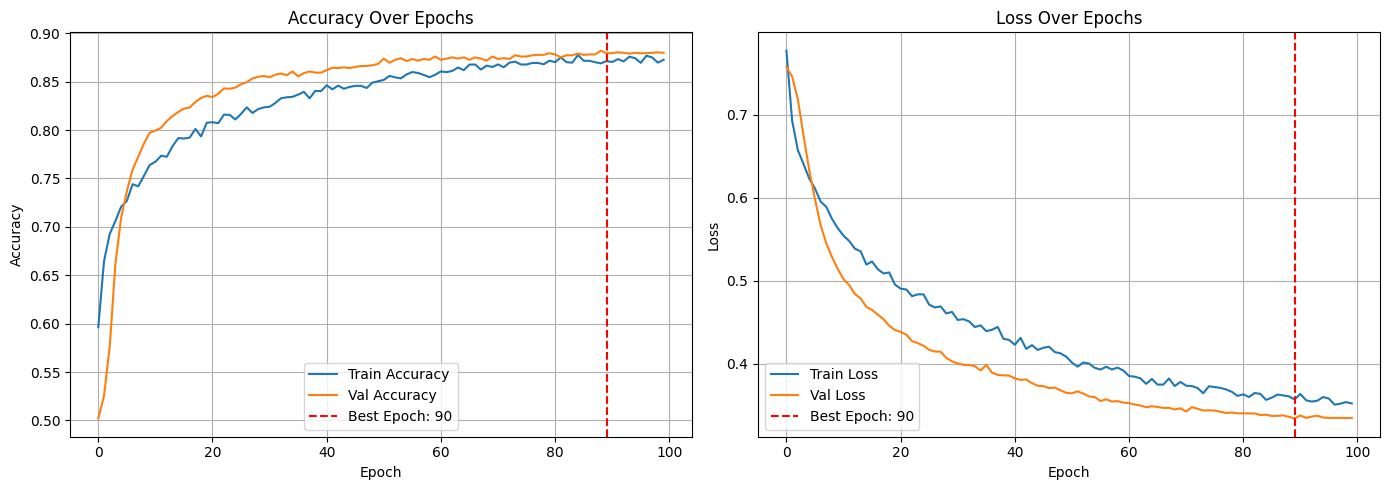

In [ ]:
# Plot training & validation accuracy and loss
plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.axvline(x=best_dnn_epoch - 1, color='r', linestyle='--', label=f'Best Epoch: {best_dnn_epoch}')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.axvline(x=best_dnn_epoch - 1, color='r', linestyle='--', label=f'Best Epoch: {best_dnn_epoch}')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


Test Accuracy: 0.8772
Test Loss: 0.3408


In [ ]:
y_pred_probs = model.predict(X_test_scaled)
y_pred = (y_pred_probs > 0.5).astype("int32")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Confusion Matrix:
[[1353  109]
 [ 250 1211]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.93      0.88      1462
           1       0.92      0.83      0.87      1461

    accuracy                           0.88      2923
   macro avg       0.88      0.88      0.88      2923
weighted avg       0.88      0.88      0.88      2923



92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


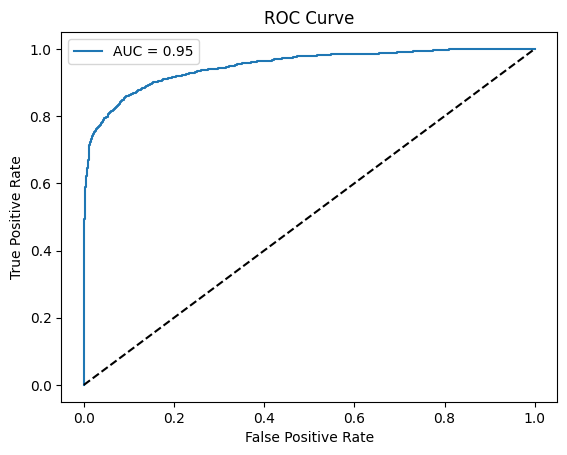

In [ ]:
y_proba = model.predict(X_test_scaled)
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


### diffrent activation layer

In [ ]:
model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train_scaled.shape[1],), kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(256, activation='tanh', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='swish', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

# Compile
model.compile(
    optimizer=Nadam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Summary
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 512)            │        10,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 189,185 (739.00 KB)

 Trainable params: 187,265 (731.50 KB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Train
history = model.fit(
    X_train_scaled, y_train,
    validation_split =0.2,
    epochs=100,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.6093 - loss: 0.8327 - val_accuracy: 0.7399 - val_loss: 0.7064
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7408 - loss: 0.5969 - val_accuracy: 0.7994 - val_loss: 0.6360
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7744 - loss: 0.5356 - val_accuracy: 0.8139 - val_loss: 0.5549
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7928 - loss: 0.5012 - val_accuracy: 0.8105 - val_loss: 0.5079
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8052 - loss: 0.4888 - val_accuracy: 0.8370 - val_loss: 0.4661
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8082 - loss: 0.4639 - val_accuracy: 0.8452 - val_loss: 0.4277
Epoch 7/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8202 - loss: 0.4606 - val_accuracy: 0.8486 - val_loss: 0.4004
Epoch 8/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8223 - loss: 0.4504 - val_accuracy: 0.

In [ ]:
# Extract metrics
dnn_train_loss = history.history['loss']
dnn_val_loss = history.history['val_loss']
dnn_train_acc = history.history['accuracy']
dnn_val_acc = history.history['val_accuracy']

# Best epoch (lowest val_loss)
best_dnn_epoch = np.argmin(dnn_val_loss) + 1

# Print results
print(f"Best Epoch: {best_dnn_epoch}")
print(f"Training Accuracy: {dnn_train_acc[best_dnn_epoch-1]:.4f}")
print(f"Validation Accuracy: {dnn_val_acc[best_dnn_epoch-1]:.4f}")
print(f"Training Loss: {dnn_train_loss[best_dnn_epoch-1]:.4f}")
print(f"Validation Loss: {dnn_val_loss[best_dnn_epoch-1]:.4f}")


Best Epoch: 48
Training Accuracy: 0.8771
Validation Accuracy: 0.8901
Training Loss: 0.3378
Validation Loss: 0.3083


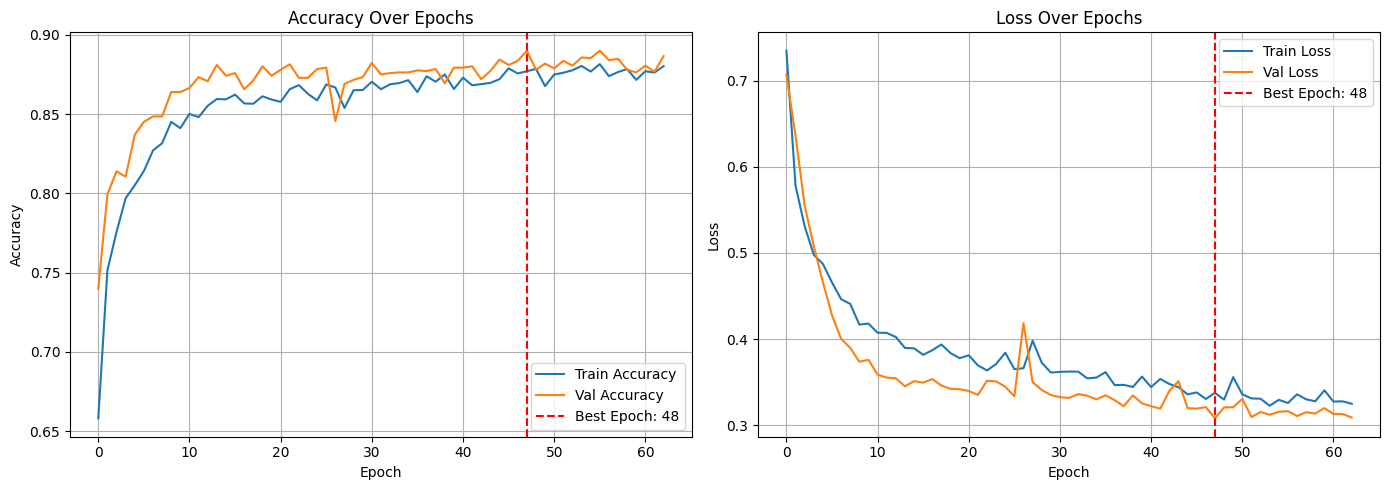

In [ ]:
# Plot training & validation accuracy and loss
plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.axvline(x=best_dnn_epoch - 1, color='r', linestyle='--', label=f'Best Epoch: {best_dnn_epoch}')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.axvline(x=best_dnn_epoch - 1, color='r', linestyle='--', label=f'Best Epoch: {best_dnn_epoch}')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


Test Accuracy: 0.8830
Test Loss: 0.3190


In [ ]:
y_pred_probs = model.predict(X_test_scaled)
y_pred = (y_pred_probs > 0.5).astype("int32")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Confusion Matrix:
[[1343  119]
 [ 223 1238]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      1462
           1       0.91      0.85      0.88      1461

    accuracy                           0.88      2923
   macro avg       0.88      0.88      0.88      2923
weighted avg       0.88      0.88      0.88      2923



92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


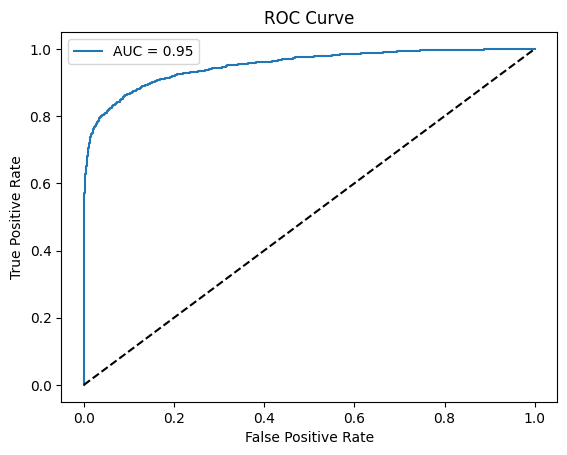

In [ ]:
y_proba = model.predict(X_test_scaled)
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


## Hyper Parameter tuining DNN
We optimize model performance using Random Search and Keras Tuner.

### HYPER PARAMETER

In [ ]:
def build_model(hp):
    model = Sequential()

    all_activations = ['relu', 'tanh', 'swish', 'sigmoid', 'selu', 'elu', 'gelu', 'softplus']
    all_optimizers = ['adam', 'nadam', 'sgd', 'rmsprop']
    lr = hp.Choice('lr', [1e-2, 1e-3, 1e-4])

    # Layer 1
    model.add(Dense(units=hp.Int('units1', min_value=64, max_value=512, step=64),
                    activation=hp.Choice('act1', all_activations),
                    input_shape=(X_train.shape[1],)))
    model.add(Dropout(hp.Float('dropout1', 0.1, 0.5, step=0.1)))

    # Layer 2
    model.add(Dense(units=hp.Int('units2', min_value=64, max_value=256, step=64),
                    activation=hp.Choice('act2', all_activations)))
    model.add(Dropout(hp.Float('dropout2', 0.1, 0.5, step=0.1)))

    # Output
    model.add(Dense(1, activation='sigmoid'))

    # Optimizer selection
    opt_choice = hp.Choice('optimizer', all_optimizers)
    if opt_choice == 'adam':
        optimizer = Adam(learning_rate=lr)
    elif opt_choice == 'nadam':
        optimizer = Nadam(learning_rate=lr)
    elif opt_choice == 'sgd':
        optimizer = SGD(learning_rate=lr, momentum=0.9, nesterov=True)
    elif opt_choice == 'rmsprop':
        optimizer = RMSprop(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    model.summary()

    return model


In [ ]:
shutil.rmtree('tuner_dir', ignore_errors=True)

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='tuner_dir',
    project_name='dnn_tuning'
)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,569 (21.75 KB)

 Trainable params: 5,569 (21.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
tuner.search(
    X_train_scaled,
    y_train,
    epochs=50,
    validation_split=0.2,
    batch_size=128,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose = 1
)
best_model = tuner.get_best_models(num_models=1)[0]


Trial 10 Complete [00h 00m 18s]
val_accuracy: 0.8678357601165771

Best val_accuracy So Far: 0.8772454857826233
Total elapsed time: 00h 04m 27s


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 192)            │         4,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,449 (64.25 KB)

 Trainable params: 16,449 (64.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Evaluate the model and unpack all returned values
test_loss, test_acc = best_model.evaluate(X_test_scaled, y_test, verbose=1)

# Print the desired metrics
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8701 - loss: 0.3034

Test Accuracy: 0.8707
Test Loss: 0.3012


In [ ]:
y_pred_probs = best_model.predict(X_test_scaled).ravel()
y_pred = (y_pred_probs > 0.5).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix:
[[1381   81]
 [ 297 1164]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.94      0.88      1462
           1       0.93      0.80      0.86      1461

    accuracy                           0.87      2923
   macro avg       0.88      0.87      0.87      2923
weighted avg       0.88      0.87      0.87      2923



92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


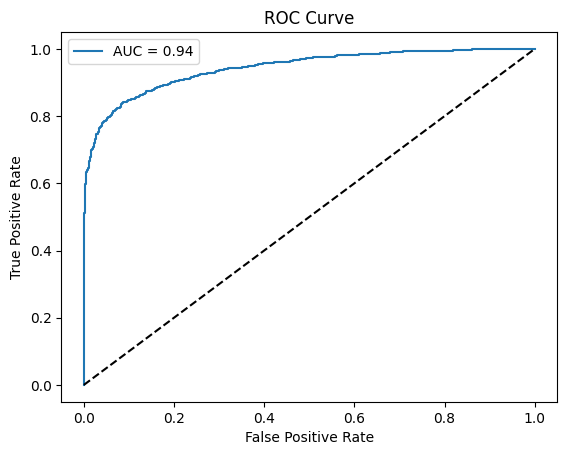

In [ ]:
y_proba = best_model.predict(X_test_scaled)
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


# Building 1D CNN
We design a 1D Convolutional Neural Network to extract local feature patterns.

## base model

In [ ]:
cnn_model = Sequential([
    InputLayer(input_shape=(X_train_scaled.shape[1], 1)),
    Conv1D(32, kernel_size=2, activation='relu'),
    Flatten(),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 19, 32)         │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 608)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           609 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 705 (2.75 KB)

 Trainable params: 705 (2.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the CNN
history = cnn_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=128,
    verbose=1
)

Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6455 - loss: 0.6655 - val_accuracy: 0.7066 - val_loss: 0.6007
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7239 - loss: 0.5772 - val_accuracy: 0.7361 - val_loss: 0.5474
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7306 - loss: 0.5416 - val_accuracy: 0.7536 - val_loss: 0.5201
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7509 - loss: 0.5175 - val_accuracy: 0.7652 - val_loss: 0.5019
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7585 - loss: 0.4975 - val_accuracy: 0.7703 - val_loss: 0.4850
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7746 - loss: 0.4844 - val_accuracy: 0.7806 - val_loss: 0.4713
Epoch 7/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7832 - loss: 0.4758 - val_accuracy: 0.7874 - val_loss: 0.4605
Epoch 8/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7854 - loss: 0.4655 - val_accuracy: 0.7908 - v

In [ ]:
# Extract metrics
cnn_train_loss = history.history['loss']
cnn_val_loss = history.history['val_loss']
cnn_train_acc = history.history['accuracy']
cnn_val_acc = history.history['val_accuracy']

# Best epoch (lowest val_loss)
best_cnn_epoch = np.argmin(cnn_val_loss) + 1

# Print results
print(f"Best Epoch: {best_cnn_epoch}")
print(f"Training Accuracy: {cnn_train_acc[best_cnn_epoch-1]:.4f}")
print(f"Validation Accuracy: {cnn_val_acc[best_cnn_epoch-1]:.4f}")
print(f"Training Loss: {cnn_train_loss[best_cnn_epoch-1]:.4f}")
print(f"Validation Loss: {cnn_val_loss[best_cnn_epoch-1]:.4f}")

Best Epoch: 100
Training Accuracy: 0.8654
Validation Accuracy: 0.8653
Training Loss: 0.3091
Validation Loss: 0.3036


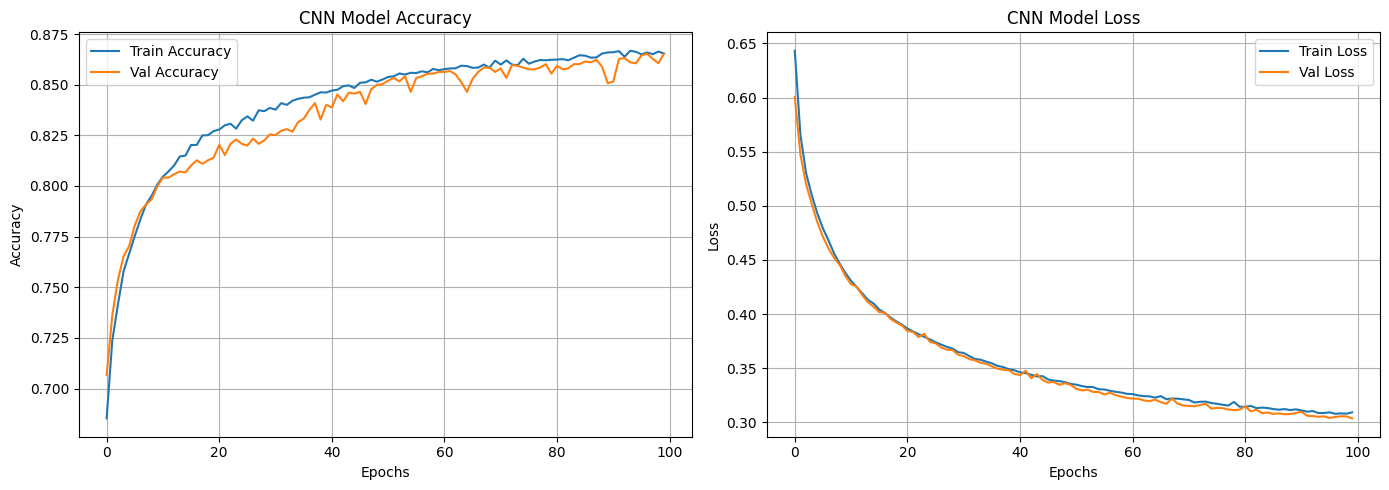

In [ ]:
# Plot accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('CNN Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('CNN Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
test_loss, test_accuracy = cnn_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


Test Accuracy: 0.8720
Test Loss: 0.3060


In [ ]:
# Final predictions
# Predict probabilities
y_test_probs = cnn_model.predict(X_test_scaled) # This line was missing
y_test_final_preds = (y_test_probs > 0.5).astype("int32")

# Evaluation
print("\nConfusion Matrix (Test Data):")
print(confusion_matrix(y_test, y_test_final_preds))

print("\nClassification Report (Test Data):")
print(classification_report(y_test, y_test_final_preds))

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Confusion Matrix (Test Data):
[[1343  119]
 [ 255 1206]]

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1462
           1       0.91      0.83      0.87      1461

    accuracy                           0.87      2923
   macro avg       0.88      0.87      0.87      2923
weighted avg       0.88      0.87      0.87      2923



92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


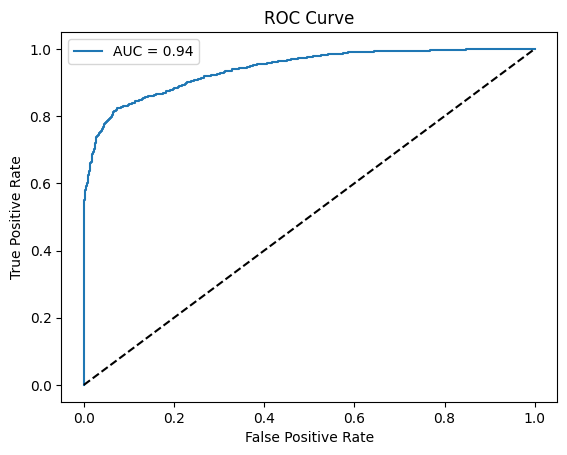

In [ ]:
y_proba = cnn_model.predict(X_test_scaled)
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


## Tuning

### Adding layers

In [ ]:
# === Define model ===
cnn_model = Sequential([
    InputLayer(input_shape=(X_train_scaled.shape[1], 1)),

    Conv1D(64, kernel_size=2, activation='relu', kernel_regularizer=l2(0.0005)),
    Dropout(0.3),

    Conv1D(32, kernel_size=2, activation='relu', kernel_regularizer=l2(0.0005)),
    Dropout(0.3),

    Conv1D(16, kernel_size=2, activation='relu', kernel_regularizer=l2(0.0005)),
    Dropout(0.3),

    Flatten(),

    Dense(128, activation='relu', kernel_regularizer=l2(0.0005)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=l2(0.0005)),

    Dense(1, activation='sigmoid')
])

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 19, 64)         │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 18, 32)         │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 18, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 17, 16)         │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 17, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 272)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,625 (189.94 KB)

 Trainable params: 48,625 (189.94 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, min_delta=0.001, restore_best_weights=True)

# Train the CNN
history = cnn_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6049 - loss: 0.7917 - val_accuracy: 0.7275 - val_loss: 0.6373
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7166 - loss: 0.6555 - val_accuracy: 0.7340 - val_loss: 0.6255
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7499 - loss: 0.5958 - val_accuracy: 0.7960 - val_loss: 0.5092
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7780 - loss: 0.5312 - val_accuracy: 0.8221 - val_loss: 0.4650
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7937 - loss: 0.5091 - val_accuracy: 0.8152 - val_loss: 0.4532
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7954 - loss: 0.4933 - val_accuracy: 0.8345 - val_loss: 0.4352
Epoch 7/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8088 - loss: 0.4700 - val_accuracy: 0.8358 - val_loss: 0.4227
Epoch 8/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8206 - loss: 0.4631 - val_accuracy: 0.

In [ ]:
# Extract metrics
cnn_train_loss = history.history['loss']
cnn_val_loss = history.history['val_loss']
cnn_train_acc = history.history['accuracy']
cnn_val_acc = history.history['val_accuracy']

# Best epoch (lowest val_loss)
best_cnn_epoch = np.argmin(cnn_val_loss) + 1

# Print results
print(f"Best Epoch: {best_cnn_epoch}")
print(f"Training Accuracy: {cnn_train_acc[best_cnn_epoch-1]:.4f}")
print(f"Validation Accuracy: {cnn_val_acc[best_cnn_epoch-1]:.4f}")
print(f"Training Loss: {cnn_train_loss[best_cnn_epoch-1]:.4f}")
print(f"Validation Loss: {cnn_val_loss[best_cnn_epoch-1]:.4f}")

Best Epoch: 34
Training Accuracy: 0.8433
Validation Accuracy: 0.8601
Training Loss: 0.3863
Validation Loss: 0.3533


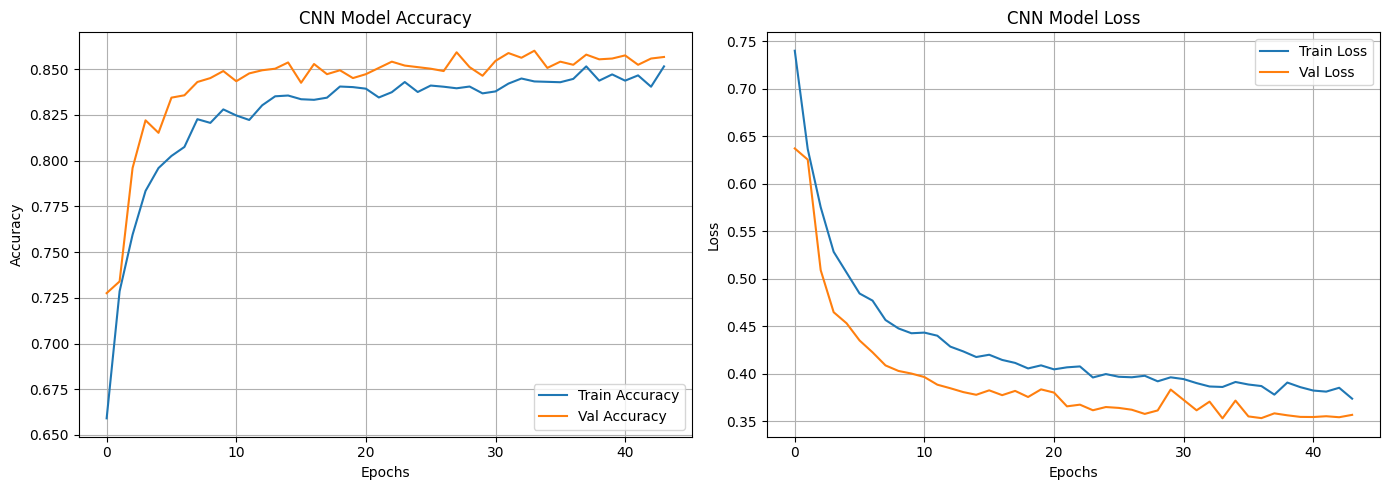

In [ ]:
# Plot accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('CNN Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('CNN Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
test_loss, test_precision= cnn_model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


Test Accuracy: 0.8720
Test Loss: 0.3587


In [ ]:
# Predict probabilities
y_test_probs = cnn_model.predict(X_test_scaled)

# Final predictions using best threshold
y_test_final_preds = (y_test_probs > 0.5).astype("int32")

# Evaluation
print("\nConfusion Matrix (Test Data):")
print(confusion_matrix(y_test, y_test_final_preds))

print("\nClassification Report (Test Data):")
print(classification_report(y_test, y_test_final_preds))


92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Confusion Matrix (Test Data):
[[1301  161]
 [ 251 1210]]

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1462
           1       0.88      0.83      0.85      1461

    accuracy                           0.86      2923
   macro avg       0.86      0.86      0.86      2923
weighted avg       0.86      0.86      0.86      2923



92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


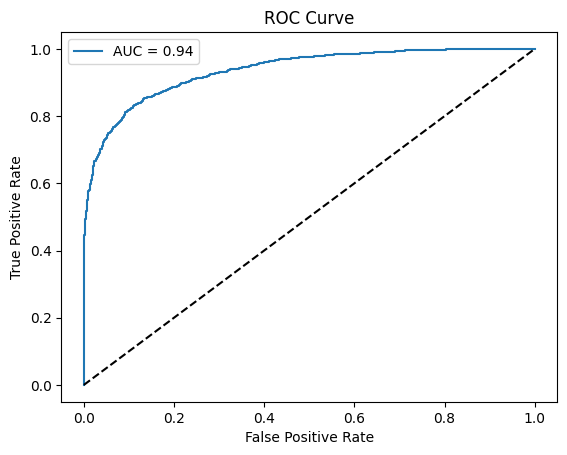

In [ ]:
y_proba = cnn_model.predict(X_test_scaled)
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


### Deeper

In [ ]:
# Deep CNN model
cnn_model = Sequential([
    InputLayer(input_shape=(X_train_scaled.shape[1], 1)),

    Conv1D(128, kernel_size=2, activation='relu', kernel_regularizer=l2(0.0005)),
    Dropout(0.3),
    Conv1D(64, kernel_size=2, activation='relu', kernel_regularizer=l2(0.0005)),
    Dropout(0.3),
    Conv1D(32, kernel_size=2, activation='relu', kernel_regularizer=l2(0.0005)),
    Dropout(0.3),

    Flatten(),

    Dense(256, activation='relu', kernel_regularizer=l2(0.0005)),
    Dropout(0.3),
    Dense(128, activation='relu', kernel_regularizer=l2(0.0005)),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer=l2(0.0005)),

    Dense(1, activation='sigmoid')
])

cnn_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 19, 128)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 19, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 18, 64)         │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 18, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 17, 32)         │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 17, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 544)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       139,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,697 (787.88 KB)

 Trainable params: 201,697 (787.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Training
history = cnn_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.6222 - loss: 0.9237 - val_accuracy: 0.7635 - val_loss: 0.6574
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.7621 - loss: 0.6485 - val_accuracy: 0.8097 - val_loss: 0.5365
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.7915 - loss: 0.5613 - val_accuracy: 0.8349 - val_loss: 0.4838
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.8090 - loss: 0.5198 - val_accuracy: 0.8366 - val_loss: 0.4621
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.8105 - loss: 0.5098 - val_accuracy: 0.8447 - val_loss: 0.4309
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.8204 - loss: 0.4831 - val_accuracy: 0.8409 - val_loss: 0.4305
Epoch 7/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8322 - loss: 0.4610 - val_accuracy: 0.8507 - val_loss: 0.4133
Epoch 8/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.8373 - loss: 0.4508 - val_accuracy: 0.

In [ ]:
# Extract metrics
cnn_train_loss = history.history['loss']
cnn_val_loss = history.history['val_loss']
cnn_train_acc = history.history['accuracy']
cnn_val_acc = history.history['val_accuracy']

# Best epoch (lowest val_loss)
best_cnn_epoch = np.argmin(cnn_val_loss) + 1

# Print results
print(f"Best Epoch: {best_cnn_epoch}")
print(f"Training Accuracy: {cnn_train_acc[best_cnn_epoch-1]:.4f}")
print(f"Validation Accuracy: {cnn_val_acc[best_cnn_epoch-1]:.4f}")
print(f"Training Loss: {cnn_train_loss[best_cnn_epoch-1]:.4f}")
print(f"Validation Loss: {cnn_val_loss[best_cnn_epoch-1]:.4f}")

Best Epoch: 38
Training Accuracy: 0.8487
Validation Accuracy: 0.8606
Training Loss: 0.3845
Validation Loss: 0.3518


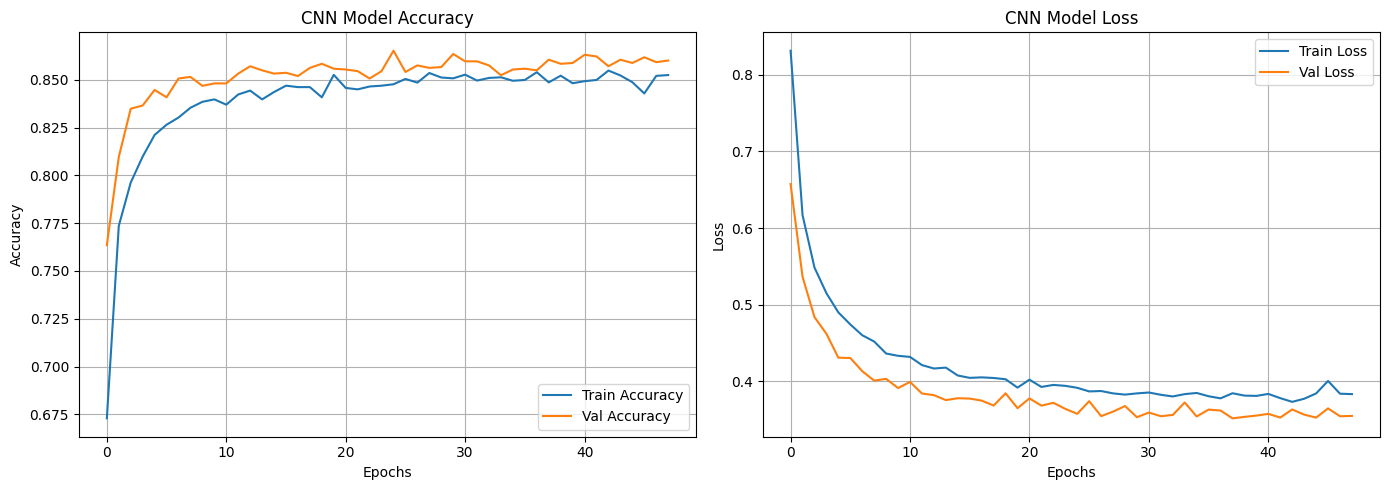

In [ ]:
# Plot accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('CNN Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('CNN Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# Evaluate the model and unpack all returned values
test_loss, test_accuracy = cnn_model.evaluate(X_test_scaled, y_test, verbose=0) # Changed X_train_scaled to X_test_scaled

# Print the desired metrics
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


Test Accuracy: 0.8604
Test Loss: 0.3529


In [ ]:
# Predict probabilities
y_test_probs = cnn_model.predict(X_test_scaled)

# Final predictions using best threshold
y_test_final_preds = (y_test_probs > 0.5).astype("int32")

# Evaluation
print("\nConfusion Matrix (Test Data):")
print(confusion_matrix(y_test, y_test_final_preds))

print("\nClassification Report (Test Data):")
print(classification_report(y_test, y_test_final_preds))


92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

Confusion Matrix (Test Data):
[[1345  117]
 [ 291 1170]]

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1462
           1       0.91      0.80      0.85      1461

    accuracy                           0.86      2923
   macro avg       0.87      0.86      0.86      2923
weighted avg       0.87      0.86      0.86      2923



92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


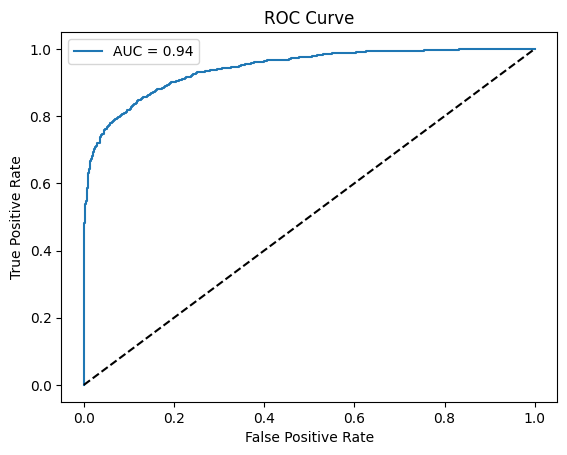

In [ ]:
y_proba = cnn_model.predict(X_test_scaled)
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


## Hyperparameters Tuning CNN
We optimize model performance using Random Search and Keras Tuner.

In [ ]:
def build_model(hp):
    model = Sequential()
    model.add(InputLayer(input_shape=(X_train_scaled.shape[1], 1)))

    all_activations = ['relu', 'tanh', 'swish', 'sigmoid', 'selu', 'elu', 'gelu', 'softplus']

    # Conv1D Layers
    for i in range(hp.Int('conv_blocks', 2, 4)):
        model.add(Conv1D(
            filters=hp.Choice(f'filters_{i}', [32, 64, 128]),
            kernel_size=hp.Choice(f'kernel_{i}', [2, 3]),
            activation=hp.Choice(f'conv_activation_{i}', all_activations),
            kernel_regularizer=l2(0.0005)
        ))
        model.add(Dropout(hp.Float(f'dropout_{i}', 0.2, 0.5, step=0.1)))

    model.add(Flatten())

    # Dense Layers
    for j in range(hp.Int('dense_layers', 2, 3)):
        model.add(Dense(
            units=hp.Choice(f'dense_units_{j}', [64, 128, 256]),
            activation=hp.Choice(f'dense_activation_{j}', all_activations),
            kernel_regularizer=l2(0.0005)
        ))
        model.add(Dropout(hp.Float(f'dropout_dense_{j}', 0.2, 0.5, step=0.1)))

    model.add(Dense(1, activation='sigmoid'))

    # Optimizer Choice
    optimizer_choice = hp.Choice('optimizer', ['adam', 'nadam', 'sgd', 'rmsprop'])
    lr = hp.Choice('lr', [1e-2, 1e-3, 1e-4])

    if optimizer_choice == 'adam':
        optimizer = Adam(learning_rate=lr)
    elif optimizer_choice == 'nadam':
        optimizer = Nadam(learning_rate=lr)
    elif optimizer_choice == 'sgd':
        optimizer = SGD(learning_rate=lr, momentum=0.9, nesterov=True)
    elif optimizer_choice == 'rmsprop':
        optimizer = RMSprop(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    model.summary()

    return model


In [ ]:
tuner = RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='dnn_tuning',
    project_name='churn_predictor'
)


Reloading Tuner from dnn_tuning/churn_predictor/tuner0.json


In [ ]:
tuner.search(
    X_train_scaled,
    y_train,
    epochs=50,
    validation_split=0.2,
    batch_size=128,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose = 1
)
best_model = tuner.get_best_models(num_models=1)[0]


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 18, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 18, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 16, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 15, 32)         │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 480)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        30,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,185 (379.63 KB)

 Trainable params: 97,185 (379.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Evaluate the model and unpack all returned values
test_loss, test_acc = best_model.evaluate(X_test_scaled, y_test, verbose=1)

# Print the desired metrics
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7314 - loss: 0.6037

Test Accuracy: 0.8604
Test Loss: 0.6046


In [ ]:
y_pred_probs = best_model.predict(X_test_scaled).ravel()
y_pred = (y_pred_probs > 0.5).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Confusion Matrix:
[[1156  306]
 [ 487  974]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.79      0.74      1462
           1       0.76      0.67      0.71      1461

    accuracy                           0.73      2923
   macro avg       0.73      0.73      0.73      2923
weighted avg       0.73      0.73      0.73      2923



92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


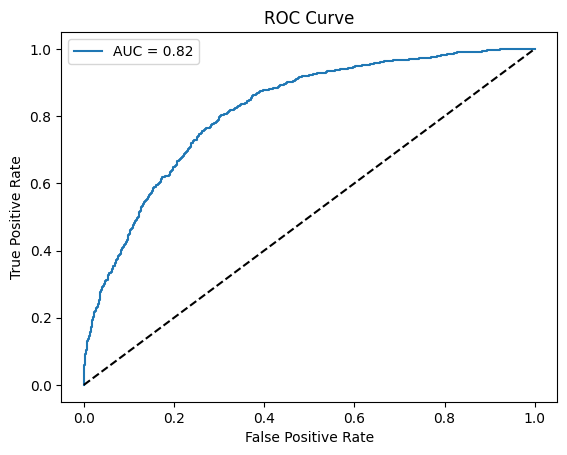

In [ ]:
y_proba = best_model.predict(X_test_scaled)
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


# Building LSTM
We build an LSTM network to capture sequential dependencies.

In [ ]:
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))


## Base Model

In [ ]:
model = Sequential([
    Input(shape=(1, X_train_scaled.shape[1])),
    LSTM(32),
    Dense(1, activation='sigmoid')
])
# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         6,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,817 (26.63 KB)

 Trainable params: 6,817 (26.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10, min_delta=0.001,
    restore_best_weights=True)

# Train
history = model.fit(
    X_train_lstm, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)



Epoch 1/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5831 - loss: 0.6789 - val_accuracy: 0.7049 - val_loss: 0.6279
Epoch 2/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7131 - loss: 0.6041 - val_accuracy: 0.7237 - val_loss: 0.5538
Epoch 3/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7325 - loss: 0.5433 - val_accuracy: 0.7476 - val_loss: 0.5212
Epoch 4/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7446 - loss: 0.5227 - val_accuracy: 0.7549 - val_loss: 0.5008
Epoch 5/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7574 - loss: 0.5056 - val_accuracy: 0.7669 - val_loss: 0.4857
Epoch 6/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7719 - loss: 0.4769 - val_accuracy: 0.7789 - val_loss: 0.4713
Epoch 7/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7851 - loss: 0.4643 - val_accuracy: 0.7840 - val_loss: 0.4579
Epoch 8/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7906 - loss: 0.4583 - val_accuracy: 0.7956 - v

In [ ]:
# Extract metrics
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Best epoch (lowest val_loss)
best_epoch = np.argmin(val_loss) + 1

# Print results
print(f"Best Epoch: {best_epoch}")
print(f"Training Accuracy: {train_acc[best_epoch-1]:.4f}")
print(f"Validation Accuracy: {val_acc[best_epoch-1]:.4f}")
print(f"Training Loss: {train_loss[best_epoch-1]:.4f}")
print(f"Validation Loss: {val_loss[best_epoch-1]:.4f}")

Best Epoch: 162
Training Accuracy: 0.8835
Validation Accuracy: 0.8743
Training Loss: 0.2749
Validation Loss: 0.2794


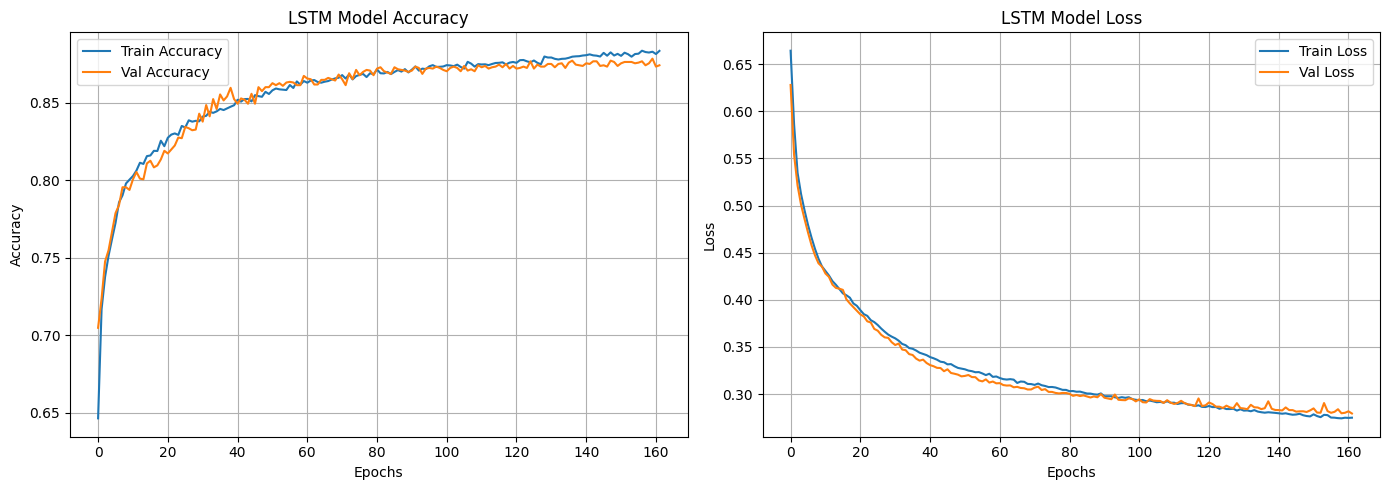

In [ ]:
# Plot accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('LSTM Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
test_loss, test_accuracy = model.evaluate(X_test_lstm, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


Test Accuracy: 0.8755
Test Loss: 0.2892


In [ ]:
# Predict probabilities
y_test_probs = model.predict(X_test_lstm)

# Final predictions using best threshold
y_test_final_preds = (y_test_probs > 0.5).astype("int32")

# Evaluation
print("\nConfusion Matrix (Test Data):")
print(confusion_matrix(y_test, y_test_final_preds))

print("\nClassification Report (Test Data):")
print(classification_report(y_test, y_test_final_preds))


92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Confusion Matrix (Test Data):
[[1335  127]
 [ 237 1224]]

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1462
           1       0.91      0.84      0.87      1461

    accuracy                           0.88      2923
   macro avg       0.88      0.88      0.88      2923
weighted avg       0.88      0.88      0.88      2923



92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


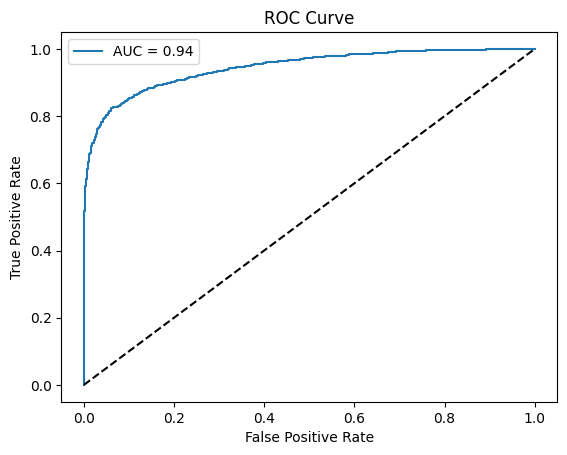

In [ ]:
y_proba = model.predict(X_test_lstm)
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


## Tuning

###  Dropout, BatchNorm, and Class Weights

In [ ]:
X_train_lstm = X_train_scaled.reshape(-1, 1, X_train_scaled.shape[1])
X_test_lstm = X_test_scaled.reshape(-1, 1, X_test_scaled.shape[1])


In [ ]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(1, X_train_scaled.shape[1])),
    BatchNormalization(),
    Dropout(0.3),

    LSTM(32),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 1, 64)          │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,649 (139.25 KB)

 Trainable params: 35,457 (138.50 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

cw = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
cw_dict = dict(enumerate(cw))

history = model.fit(
    X_train_lstm, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=128,
    callbacks=[early_stop, lr_schedule],
    class_weight=cw_dict,
    verbose=1
)

Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.6139 - loss: 0.6895 - val_accuracy: 0.4885 - val_loss: 0.6893 - learning_rate: 5.0000e-04
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7353 - loss: 0.5313 - val_accuracy: 0.5047 - val_loss: 0.6805 - learning_rate: 5.0000e-04
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7683 - loss: 0.4805 - val_accuracy: 0.6809 - val_loss: 0.6598 - learning_rate: 5.0000e-04
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7832 - loss: 0.4591 - val_accuracy: 0.7639 - val_loss: 0.6179 - learning_rate: 5.0000e-04
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8021 - loss: 0.4221 - val_accuracy: 0.7968 - val_loss: 0.5561 - learning_rate: 5.0000e-04
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8087 - loss: 0.4144 - val_accuracy: 0.8161 - val_loss: 0.4874 - learning_rate: 5.0000e-04
Epoch 7/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8118

In [ ]:
# Extract metrics
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Best epoch (lowest val_loss)
best_epoch = np.argmin(val_loss) + 1

# Print results
print(f"Best Epoch: {best_epoch}")
print(f"Training Accuracy: {train_acc[best_epoch-1]:.4f}")
print(f"Validation Accuracy: {val_acc[best_epoch-1]:.4f}")
print(f"Training Loss: {train_loss[best_epoch-1]:.4f}")
print(f"Validation Loss: {val_loss[best_epoch-1]:.4f}")

Best Epoch: 91
Training Accuracy: 0.8795
Validation Accuracy: 0.8879
Training Loss: 0.2741
Validation Loss: 0.2600


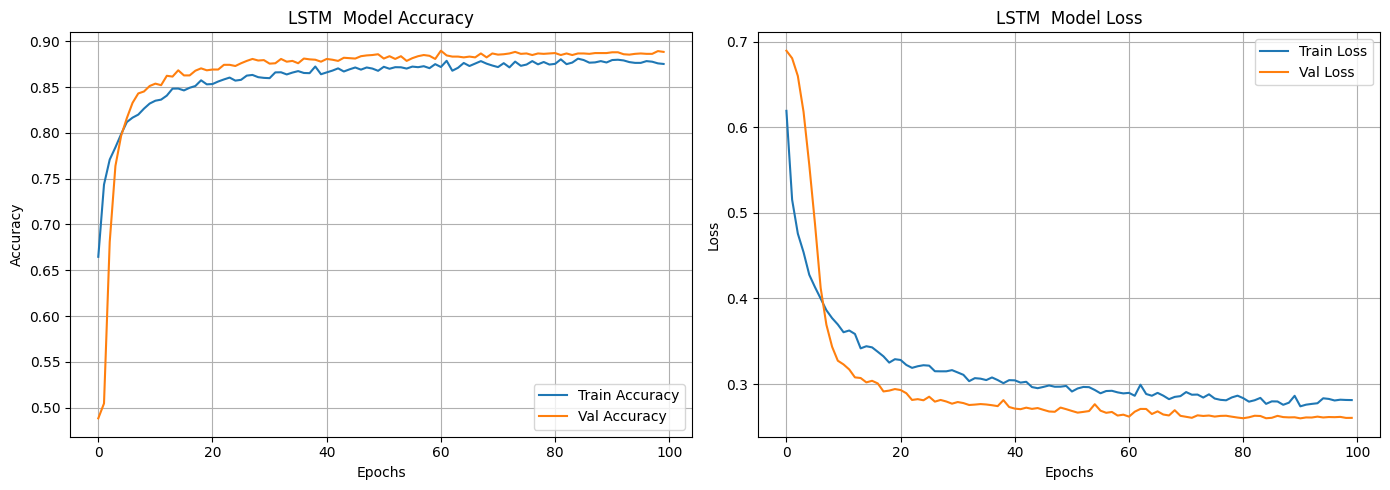

In [ ]:
# Plot accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('LSTM  Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM  Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
test_loss, test_accuracy = model.evaluate(X_test_lstm, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


Test Accuracy: 0.8837
Test Loss: 0.2655


In [ ]:
# Predict probabilities
y_test_probs = model.predict(X_test_lstm)

# Final predictions using best threshold
y_test_final_preds = (y_test_probs > 0.5).astype("int32")

# Evaluation
print("\nConfusion Matrix (Test Data):")
print(confusion_matrix(y_test, y_test_final_preds))

print("\nClassification Report (Test Data):")
print(classification_report(y_test, y_test_final_preds))


92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

Confusion Matrix (Test Data):
[[1362  100]
 [ 240 1221]]

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.85      0.93      0.89      1462
           1       0.92      0.84      0.88      1461

    accuracy                           0.88      2923
   macro avg       0.89      0.88      0.88      2923
weighted avg       0.89      0.88      0.88      2923



92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


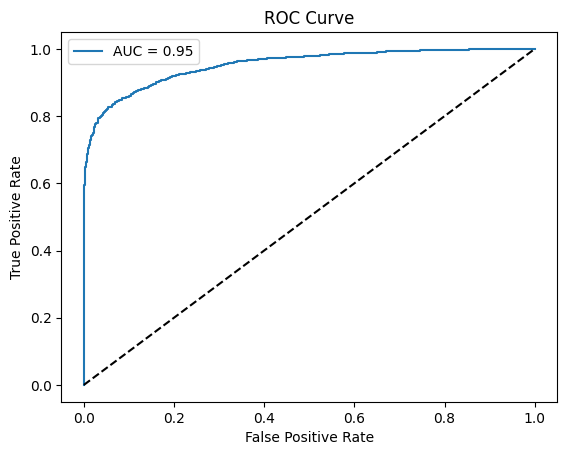

In [ ]:
y_proba = model.predict(X_test_lstm)
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


### Increasing model capacity

In [ ]:
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(1, X_train_scaled.shape[1])),
    BatchNormalization(),
    Dropout(0.3),

    LSTM(64),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='sigmoid')
])
optimizer = Adam(learning_rate=1e-4)
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 1, 128)         │        76,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,577 (502.25 KB)

 Trainable params: 128,193 (500.75 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

cw = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
cw_dict = dict(enumerate(cw))

history = model.fit(
    X_train_lstm, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=128,
    callbacks=[early_stop, lr_schedule],
    class_weight=cw_dict,
    verbose=1
)

Epoch 1/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.5726 - loss: 0.7443 - val_accuracy: 0.4885 - val_loss: 0.6904 - learning_rate: 1.0000e-04
Epoch 2/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6806 - loss: 0.6005 - val_accuracy: 0.5436 - val_loss: 0.6860 - learning_rate: 1.0000e-04
Epoch 3/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7130 - loss: 0.5661 - val_accuracy: 0.6437 - val_loss: 0.6772 - learning_rate: 1.0000e-04
Epoch 4/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7439 - loss: 0.5278 - val_accuracy: 0.6908 - val_loss: 0.6596 - learning_rate: 1.0000e-04
Epoch 5/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7515 - loss: 0.5169 - val_accuracy: 0.7421 - val_loss: 0.6272 - learning_rate: 1.0000e-04
Epoch 6/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7540 - loss: 0.5004 - val_accuracy: 0.7784 - val_loss: 0.5763 - learning_rate: 1.0000e-04
Epoch 7/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 

In [ ]:
# Extract metrics
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Best epoch (lowest val_loss)
best_epoch = np.argmin(val_loss) + 1

# Print results
print(f"Best Epoch: {best_epoch}")
print(f"Training Accuracy: {train_acc[best_epoch-1]:.4f}")
print(f"Validation Accuracy: {val_acc[best_epoch-1]:.4f}")
print(f"Training Loss: {train_loss[best_epoch-1]:.4f}")
print(f"Validation Loss: {val_loss[best_epoch-1]:.4f}")

Best Epoch: 119
Training Accuracy: 0.8673
Validation Accuracy: 0.8828
Training Loss: 0.2998
Validation Loss: 0.2703


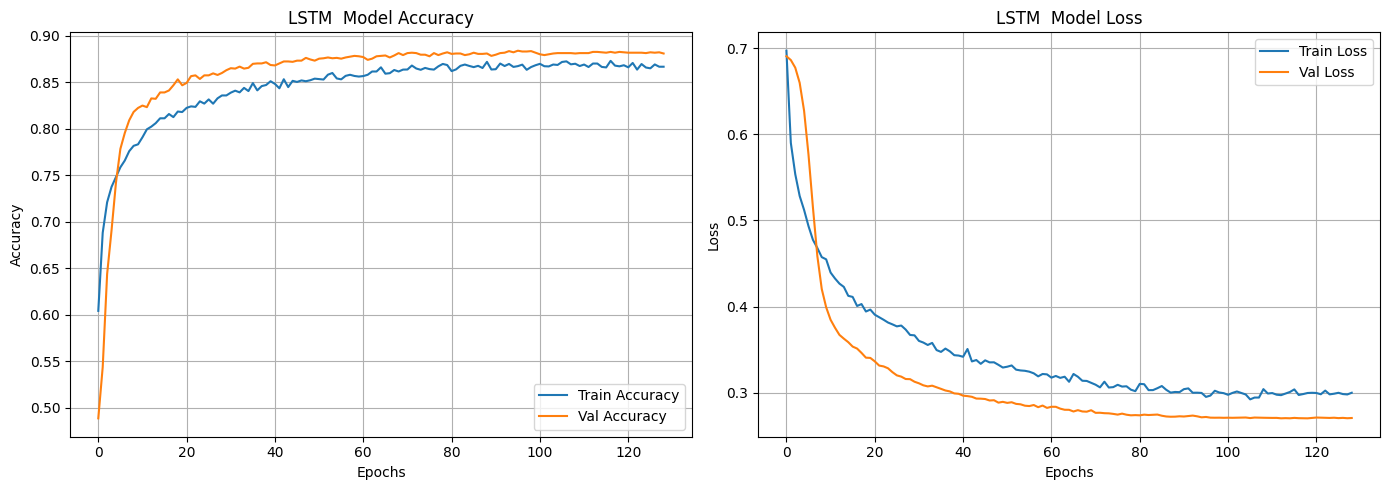

In [ ]:
# Plot accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('LSTM  Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM  Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
test_loss, test_accuracy = model.evaluate(X_test_lstm, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


Test Accuracy: 0.8796
Test Loss: 0.2796


In [ ]:
# Predict probabilities
y_test_probs = model.predict(X_test_lstm)

# Final predictions using best threshold
y_test_final_preds = (y_test_probs > 0.5).astype("int32")

# Evaluation
print("\nConfusion Matrix (Test Data):")
print(confusion_matrix(y_test, y_test_final_preds))

print("\nClassification Report (Test Data):")
print(classification_report(y_test, y_test_final_preds))


92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

Confusion Matrix (Test Data):
[[1354  108]
 [ 244 1217]]

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.85      0.93      0.88      1462
           1       0.92      0.83      0.87      1461

    accuracy                           0.88      2923
   macro avg       0.88      0.88      0.88      2923
weighted avg       0.88      0.88      0.88      2923



92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


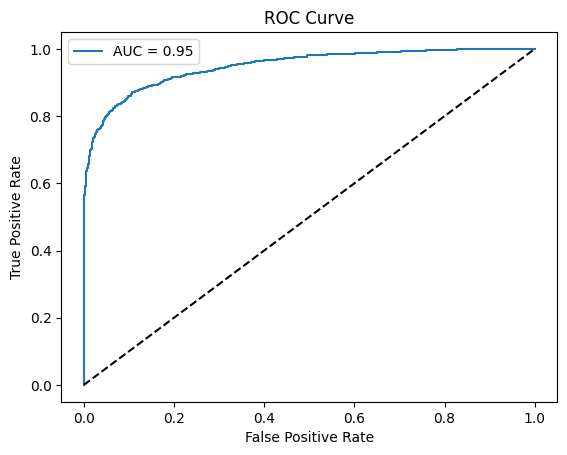

In [ ]:
y_proba = model.predict(X_test_lstm)
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


### Deeper

In [ ]:
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(1, X_train_scaled.shape[1])),
    BatchNormalization(),
    Dropout(0.3),

    LSTM(64),
    BatchNormalization(),
    Dropout(0.2),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
optimizer = Adam(learning_rate=1e-4)
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 1, 128)         │        76,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145,665 (569.00 KB)

 Trainable params: 145,025 (566.50 KB)

 Non-trainable params: 640 (2.50 KB)

In [ ]:
# Class weights
cw = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
cw_dict = dict(enumerate(cw))

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_acc', factor=0.5, patience=7, min_lr=1e-6)

# Training
history = model.fit(
    X_train_lstm, y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=128,
    class_weight=cw_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.5595 - loss: 0.7422 - val_accuracy: 0.4885 - val_loss: 0.6955 - learning_rate: 1.0000e-04
Epoch 2/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6531 - loss: 0.6233 - val_accuracy: 0.4885 - val_loss: 0.6992 - learning_rate: 1.0000e-04
Epoch 3/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6994 - loss: 0.5866 - val_accuracy: 0.4885 - val_loss: 0.6995 - learning_rate: 1.0000e-04
Epoch 4/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7139 - loss: 0.5665 - val_accuracy: 0.4885 - val_loss: 0.6948 - learning_rate: 1.0000e-04
Epoch 5/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7279 - loss: 0.5338 - val_accuracy: 0.5000 - val_loss: 0.6781 - learning_rate: 1.0000e-04
Epoch 6/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7477 - loss: 0.5093 - val_accuracy: 0.5932 - val_loss: 0.6439 - learning_rate: 1.0000e-04
Epoch 7/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 

In [ ]:
# Extract metrics
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Best epoch (lowest val_loss)
best_epoch = np.argmin(val_loss) + 1

# Print results
print(f"Best Epoch: {best_epoch}")
print(f"Training Accuracy: {train_acc[best_epoch-1]:.4f}")
print(f"Validation Accuracy: {val_acc[best_epoch-1]:.4f}")
print(f"Training Loss: {train_loss[best_epoch-1]:.4f}")
print(f"Validation Loss: {val_loss[best_epoch-1]:.4f}")

Best Epoch: 202
Training Accuracy: 0.8780
Validation Accuracy: 0.8905
Training Loss: 0.2772
Validation Loss: 0.2576


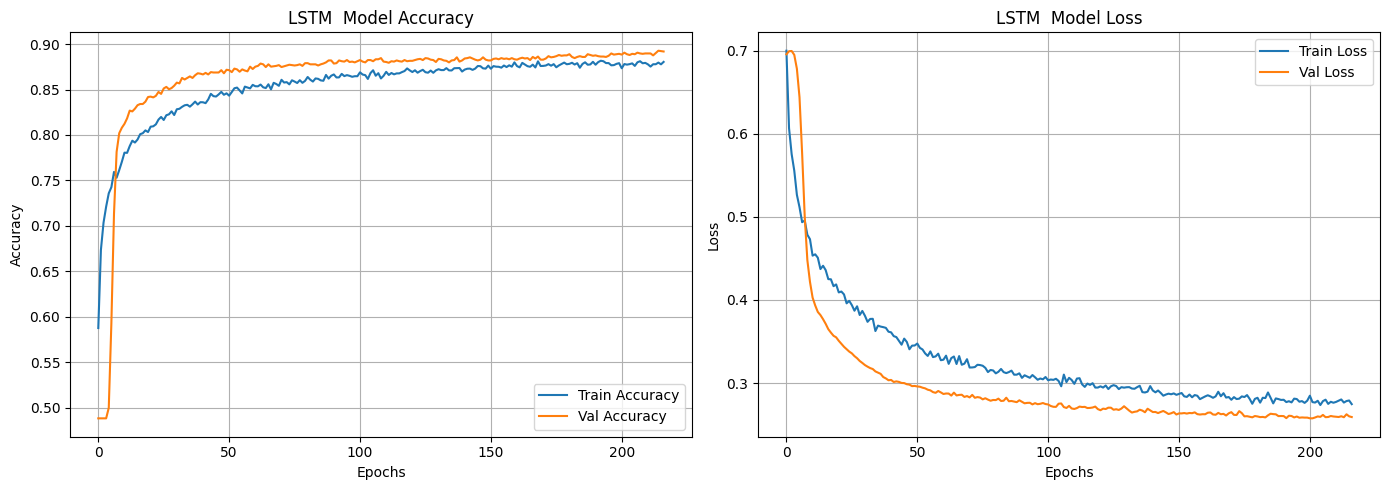

In [ ]:
# Plot accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('LSTM  Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM  Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
test_loss, test_accuracy = model.evaluate(X_test_lstm, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


Test Accuracy: 0.8868
Test Loss: 0.2628


In [ ]:
# Predict probabilities
y_test_probs = model.predict(X_test_lstm)

# Final predictions using best threshold
y_test_final_preds = (y_test_probs > 0.5).astype("int32")

# Evaluation
print("\nConfusion Matrix (Test Data):")
print(confusion_matrix(y_test, y_test_final_preds))

print("\nClassification Report (Test Data):")
print(classification_report(y_test, y_test_final_preds))


92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

Confusion Matrix (Test Data):
[[1359  103]
 [ 228 1233]]

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.86      0.93      0.89      1462
           1       0.92      0.84      0.88      1461

    accuracy                           0.89      2923
   macro avg       0.89      0.89      0.89      2923
weighted avg       0.89      0.89      0.89      2923



92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


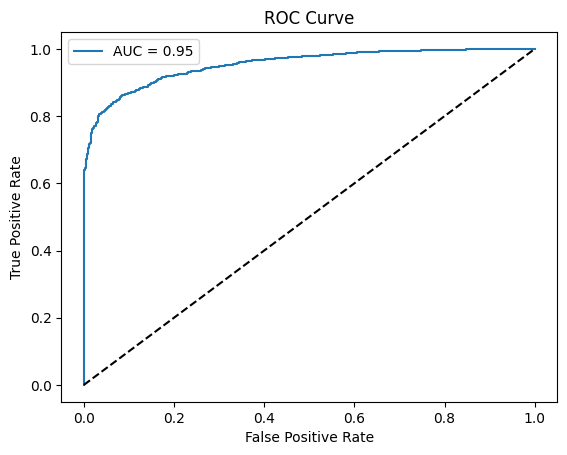

In [ ]:
y_proba = model.predict(X_test_lstm)
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


## HyperParameter Tuning LSTM
We optimize model performance using Random Search and Keras Tuner.

In [ ]:
def build_lstm_model(hp):
    model = Sequential()
    model.add(InputLayer(input_shape=(1, X_train_scaled.shape[1])))

    # LSTM layers
    model.add(LSTM(
        units=hp.Choice('lstm1_units', [64, 128, 256]),
        return_sequences=True
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float('lstm1_dropout', 0.2, 0.4, step=0.1)))

    model.add(LSTM(
        units=hp.Choice('lstm2_units', [32, 64, 128]),
        return_sequences=False
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float('lstm2_dropout', 0.2, 0.4, step=0.1)))

    # Dense layers
    for i in range(hp.Int('dense_layers', 2, 3)):
        model.add(Dense(
            units=hp.Choice(f'dense_units_{i}', [64, 128, 256]),
            activation=hp.Choice(f'dense_activation_{i}', ['relu', 'tanh', 'swish', 'selu'])
        ))
        model.add(Dropout(hp.Float(f'dense_dropout_{i}', 0.2, 0.4, step=0.1)))

    model.add(Dense(1, activation='sigmoid'))

    # Optimizer
    lr = hp.Choice('lr', [1e-2, 1e-3, 1e-4])
    opt_name = hp.Choice('optimizer', ['adam', 'nadam', 'rmsprop'])

    if opt_name == 'adam':
        optimizer = Adam(learning_rate=lr)
    elif opt_name == 'nadam':
        optimizer = Nadam(learning_rate=lr)
    else:
        optimizer = RMSprop(learning_rate=lr)

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    model.summary()

    return model


In [ ]:
tuner = RandomSearch(
    build_lstm_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='lstm_tuning',
    project_name='lstm_model'
)


Reloading Tuner from lstm_tuning/lstm_model/tuner0.json


In [ ]:
# Class weights
cw = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
cw_dict = dict(enumerate(cw))

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_acc', factor=0.5, patience=7, min_lr=1e-6)

tuner.search(
    X_train_lstm, y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    class_weight=cw_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

best_model = tuner.get_best_models(num_models=1)[0]

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 64)          │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 170,881 (667.50 KB)

 Trainable params: 170,497 (666.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
y_test_probs = best_model.predict(X_test_lstm)


# Evaluation
test_loss, test_acc = best_model.evaluate(X_test_lstm, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

Test Accuracy: 0.8888
Test Loss: 0.2559


In [ ]:
y_test_preds = (y_test_probs > 0.5).astype("int32")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_preds))

print("\nClassification Report:")
print(classification_report(y_test, y_test_preds))


Confusion Matrix:
[[1353  109]
 [ 216 1245]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.93      0.89      1462
           1       0.92      0.85      0.88      1461

    accuracy                           0.89      2923
   macro avg       0.89      0.89      0.89      2923
weighted avg       0.89      0.89      0.89      2923



92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


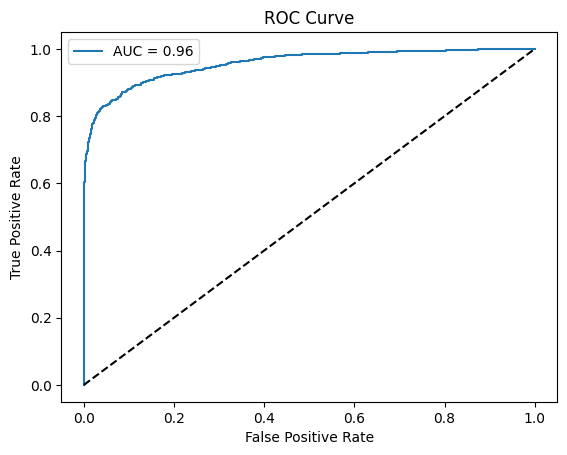

In [ ]:
y_proba = best_model.predict(X_test_lstm)
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


# **Conclusion and Future Work**
In this study, we implemented and compared three deep learning models for churn prediction: DNN, CNN, and LSTM. Each model showed strong performance, with the LSTM achieving the highest recall for churn detection. For future work, we aim to explore more advanced balancing techniques like SMOTE-ENN and investigate explainable AI approaches to increase transparency and trust in model predictions.
